# PitWall-X: Tyre Degradation, Fuel-Corrected Pace & Pit Strategy

Pipeline: Setup -> Data Loading -> EDA -> Preprocessing & Feature Engineering -> Generalising -> Modelling -> Evaluation -> Decision (MDP framing).

Developed first on a single race (Bahrain 2023), then generalised across multiple races within the same regulation era (2022-2025) via a reusable function.

## Phase 0: Setup

In [2]:
import os
import json
import time
import warnings
import datetime as dt
import logging
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from xgboost import XGBRegressor

fastf1.Cache.enable_cache("../cache/")

os.makedirs("../figs", exist_ok=True)
for _sub in ["eda","degradation_raw","degradation_corrected","screening","data","model","decision"]:
    os.makedirs(f"../figs/{_sub}", exist_ok=True)
warnings.filterwarnings("ignore")


## Phase 1: Data Loading: Bahrain Grand Prix 2023

Bahrain is the pre-season testing circuit, heavily tyre-sensitive, with lots of overtaking opportunities.  We load race laps and results.

In [3]:
bahrain2023_race = fastf1.get_session(2023, "Bahrain", "R")
bahrain2023_race.load()
laps = bahrain2023_race.laps
results = bahrain2023_race.results

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


## Phase 2: Exploratory Data Analysis (EDA)

### 2.1 Inspecting the raw data

In [4]:
print(laps.shape)
print(laps.columns)
print(laps.dtypes)
print(laps.head())

(1056, 31)
Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')
Time                  timedelta64[ns]
Driver                         object
DriverNumber                   object
LapTime               timedelta64[ns]
LapNumber                     float64
Stint                         float64
PitOutTime            timedelta64[ns]
PitInTime             timedelta64[ns]
Sector1Time           timedelta64[ns]
Sector2Time           timedelta64[ns]
Sector3Time           timedelta64[ns]
Sector1SessionTime    timedelta64[ns]
Sector2SessionTime    timedel

### 2.2 Cleaning, missing values, and stint overview
Convert lap times to seconds, cast stint to int, keep only `IsAccurate` laps, and filter to green-flag laps (`TrackStatus == '1'`). Safety-car and yellow-flag laps inflate times and are not representative of tyre degradation.

In [5]:
laps["LapTimeSeconds"] = laps["LapTime"].dt.total_seconds()
laps["Stint"] = laps["Stint"].astype(int)
clean_laps = laps[laps["IsAccurate"] == True].copy()
clean_laps = clean_laps[clean_laps["TrackStatus"].astype(str) == "1"].copy()
drivers = clean_laps["Driver"].unique()
print(f"Missed values: {clean_laps.isna().sum()}")
for d in drivers:
    ds = clean_laps[clean_laps["Driver"] == d].Stint.unique()
    print("Driver: ", d)
    print(ds)
    for s in ds:
        print(f"stint {s}: ", clean_laps[(clean_laps["Driver"] == d) & (clean_laps["Stint"] == s)].shape[0])

Missed values: Time                    0
Driver                  0
DriverNumber            0
LapTime                 0
LapNumber               0
Stint                   0
PitOutTime            889
PitInTime             889
Sector1Time             0
Sector2Time             0
Sector3Time             0
Sector1SessionTime      4
Sector2SessionTime      0
Sector3SessionTime      0
SpeedI1                 0
SpeedI2                 0
SpeedFL                 0
SpeedST                 0
IsPersonalBest          0
Compound                0
TyreLife                0
FreshTyre               0
Team                    0
LapStartTime            0
LapStartDate            0
TrackStatus             0
Position                0
Deleted                 0
DeletedReason           0
FastF1Generated         0
IsAccurate              0
LapTimeSeconds          0
dtype: int64
Driver:  VER
[1 2 3]
stint 1:  11
stint 2:  20
stint 3:  18
Driver:  GAS
[1 2 3 4]
stint 1:  6
stint 2:  14
stint 3:  13
stint 4:  16
Driver

### 2.3 Identifying finishers (official classification)

In [6]:
finisher_abbrevs = results[results["Status"].isin(["Finished", "Lapped"])]["Abbreviation"].tolist()
finisher_laps = clean_laps[clean_laps["Driver"].isin(finisher_abbrevs)].copy()
print(f"All drivers: {clean_laps['Driver'].nunique()}, finishers: {finisher_laps['Driver'].nunique()}")
drivers = finisher_laps["Driver"].unique()
print(f"Finishers: {set(drivers)}")
print(results["Status"].unique())

All drivers: 20, finishers: 17
Finishers: {'GAS', 'NOR', 'SAI', 'ALO', 'RUS', 'BOT', 'DEV', 'ZHO', 'SAR', 'HUL', 'PER', 'HAM', 'STR', 'ALB', 'TSU', 'MAG', 'VER'}
['Finished' 'Lapped' 'Retired']


### 2.4 Correlation check

In [7]:
START_FUEL = 109.0
FUEL_BURN = START_FUEL / 57
clean_laps["FuelMass"] = (START_FUEL - FUEL_BURN * clean_laps["LapNumber"]).clip(lower=0.0)
finisher_laps["FuelMass"] = (START_FUEL - FUEL_BURN * finisher_laps["LapNumber"]).clip(lower=0.0)

print("Overall correlation:")
print(clean_laps[["TyreLife", "FuelMass", "LapTimeSeconds"]].corr(), "\n")

print("Overall correlation (Finished drivers only):")
print(finisher_laps[["TyreLife", "FuelMass", "LapTimeSeconds"]].corr(), "\n")

ver_stint2 = clean_laps[(clean_laps["Driver"] == "VER") & (clean_laps["Stint"] == 2)]
print("Verstappen Stint 2 correlation:")
print(ver_stint2[["TyreLife", "FuelMass", "LapTimeSeconds"]].corr())

Overall correlation:
                TyreLife  FuelMass  LapTimeSeconds
TyreLife        1.000000 -0.512975       -0.017264
FuelMass       -0.512975  1.000000        0.691091
LapTimeSeconds -0.017264  0.691091        1.000000 

Overall correlation (Finished drivers only):
                TyreLife  FuelMass  LapTimeSeconds
TyreLife        1.000000 -0.524446       -0.033825
FuelMass       -0.524446  1.000000        0.691746
LapTimeSeconds -0.033825  0.691746        1.000000 

Verstappen Stint 2 correlation:
                TyreLife  FuelMass  LapTimeSeconds
TyreLife         1.00000  -1.00000         0.02976
FuelMass        -1.00000   1.00000        -0.02976
LapTimeSeconds   0.02976  -0.02976         1.00000


Within a stint, TyreLife and FuelMass are perfectly collinear (r = -1.00), so fuel masks degradation in raw lap time; pit-stop resets break the collinearity (~-0.53 pooled). Cross-circuit pace also dominates: the std of mean lap times across circuits is ~10.6 s versus ~1.35 s within a circuit, so circuit identity alone explains ~98% of absolute lap-time variance. We therefore model `DegradationDelta` (lap time relative to each stint's fresh pace, defined in 3.3), which removes circuit, car, and fuel level by construction and leaves the degradation signal. This matches the state-space formulation of Cappello and Hoegh (2025), who model lap time as fuel plus a latent tyre pace with pit stops as state resets.

### 2.5 Distribution and outliers

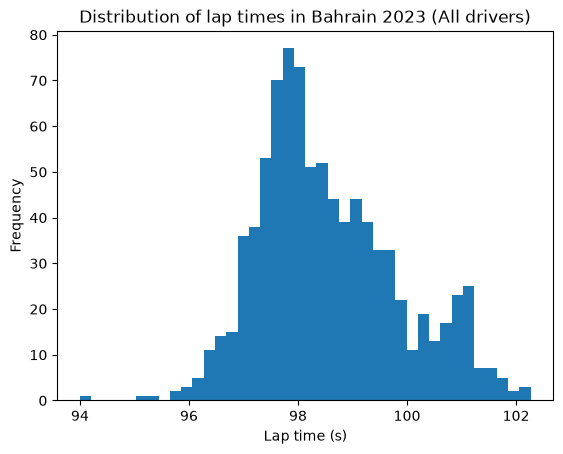

In [8]:
plt.xlabel("Lap time (s)")
plt.ylabel("Frequency")
plt.title("Distribution of lap times in Bahrain 2023 (All drivers)")
plt.hist(clean_laps["LapTimeSeconds"], bins=40)
plt.savefig("../figs/eda/laptime_distribution_all.png", dpi=120, bbox_inches="tight")
plt.show()

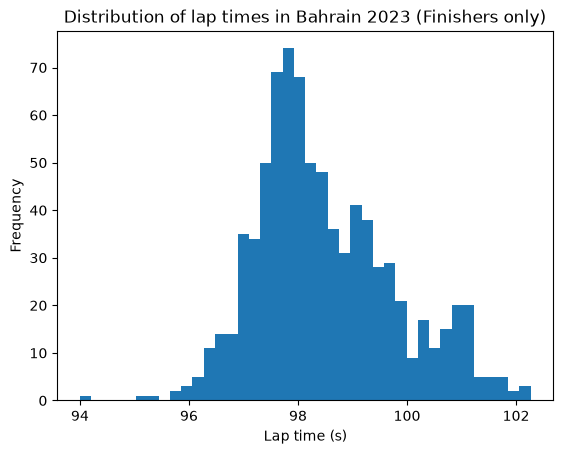

In [9]:
plt.xlabel("Lap time (s)")
plt.ylabel("Frequency")
plt.title("Distribution of lap times in Bahrain 2023 (Finishers only)")
plt.hist(finisher_laps["LapTimeSeconds"], bins=40)
plt.show()

### 2.6 Raw degradation plots per stint

In [10]:
for d in drivers:
    ds = finisher_laps[finisher_laps["Driver"] == d].Stint.unique()
    for s in ds:
        driver_stint = finisher_laps[(finisher_laps["Driver"] == d) & (finisher_laps["Stint"] == s)]
        compound = driver_stint["Compound"].iloc[0]
        plt.xlabel("Tyre Age")
        plt.ylabel("Lap Time")
        plt.title(f"{d} Stint {s} Compound: {compound} Bahrain 2023 laptime evolution by tyre age (Lower is faster)")
        plt.plot(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['LapTimeSeconds']))
        plt.scatter(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['LapTimeSeconds']))
        plt.savefig(f"../figs/degradation_raw/bahrain2023_{d}_stint{s}_{compound}_tyredeg_evo_scatter.png")
        plt.cla()
plt.close()

## Phase 3: Preprocessing & Feature Engineering

### 3.1 Estimating the fuel coefficient (gamma)
Regress lap time on tyre age and fuel mass per driver (finishers only). Pit-stop resets decouple tyre age from fuel mass, making the two effects identifiable.

In [11]:
sec_per_kg_fuel = []
for d in drivers:
    driver_laps = finisher_laps[finisher_laps["Driver"] == d].copy()
    y = driver_laps['LapTimeSeconds']
    driver_laps["FuelMass"] = (START_FUEL - FUEL_BURN * driver_laps["LapNumber"]).clip(lower=0.0)
    X = driver_laps[["TyreLife", "FuelMass"]]
    laptime_predictor = LinearRegression()
    laptime_predictor.fit(X, y)
    print(f"Driver: {d}, deg_rate = {laptime_predictor.coef_[0]:.4f}, fuel_coef = {laptime_predictor.coef_[1]:.4f}")
    sec_per_kg_fuel.append(laptime_predictor.coef_[1])
gamma = np.mean(sec_per_kg_fuel)
per_lap_gain = gamma * FUEL_BURN
race_cum_gain = per_lap_gain * 57
print(f"Mean s/kg (gamma): {gamma:.4f}")
print(f"Per-lap gain: {per_lap_gain:.4f} s")
print(f"Race-total gain: {race_cum_gain:.2f} s")

Driver: VER, deg_rate = 0.0478, fuel_coef = 0.0192
Driver: GAS, deg_rate = 0.1729, fuel_coef = 0.0514
Driver: PER, deg_rate = 0.0795, fuel_coef = 0.0278
Driver: ALO, deg_rate = 0.1116, fuel_coef = 0.0411
Driver: STR, deg_rate = 0.1274, fuel_coef = 0.0435
Driver: SAR, deg_rate = 0.1625, fuel_coef = 0.0422
Driver: MAG, deg_rate = 0.2246, fuel_coef = 0.0473
Driver: DEV, deg_rate = 0.1764, fuel_coef = 0.0499
Driver: TSU, deg_rate = 0.1598, fuel_coef = 0.0475
Driver: ALB, deg_rate = 0.1490, fuel_coef = 0.0389
Driver: ZHO, deg_rate = 0.1790, fuel_coef = 0.0567
Driver: HUL, deg_rate = 0.2226, fuel_coef = 0.0507
Driver: NOR, deg_rate = 0.0974, fuel_coef = 0.0473
Driver: HAM, deg_rate = 0.1001, fuel_coef = 0.0350
Driver: SAI, deg_rate = 0.0940, fuel_coef = 0.0307
Driver: RUS, deg_rate = 0.1118, fuel_coef = 0.0392
Driver: BOT, deg_rate = 0.1134, fuel_coef = 0.0479
Mean s/kg (gamma): 0.0421
Per-lap gain: 0.0806 s
Race-total gain: 4.59 s


### 3.2 Applying the fuel correction
`FuelCorrectedLapTime = LapTimeSeconds - gamma * FuelMass` removes the fuel-load penalty, isolating car + tyre pace.

In [12]:
finisher_laps["FuelCorrectedLapTime"] = finisher_laps["LapTimeSeconds"] - gamma * finisher_laps["FuelMass"]
print(finisher_laps[["LapNumber", "Driver", "LapTimeSeconds", "FuelMass", "FuelCorrectedLapTime"]])

      LapNumber Driver  LapTimeSeconds    FuelMass  FuelCorrectedLapTime
2           3.0    VER          98.006  103.263158             93.655174
3           4.0    VER          97.976  101.350877             93.705744
4           5.0    VER          98.035   99.438596             93.845315
5           6.0    VER          97.986   97.526316             93.876886
6           7.0    VER          98.021   95.614035             93.992457
...         ...    ...             ...         ...                   ...
1038       53.0    BOT          97.856    7.649123             97.533717
1039       54.0    BOT          97.738    5.736842             97.496287
1040       55.0    BOT          97.807    3.824561             97.645858
1041       56.0    BOT          98.160    1.912281             98.079429
1042       57.0    BOT          98.407    0.000000             98.407000

[816 rows x 5 columns]


### 3.3 StintFreshPace and DegradationDelta
`StintFreshPace` is the median of the three fastest fuel-corrected lap times in a stint. It anchors the stint and absorbs circuit identity, car pace, and driver style. Because it uses the full stint, the construction has a within-stint look-ahead; at deployment the fresh pace is estimated from the opening laps before the first pit window (laps 2 to 4). `DegradationDelta = FuelCorrectedLapTime - StintFreshPace` is the model target: near 0 on fresh tyres and rising as the tyre wears. Laps with `DegradationDelta` outside [-3, 8] s are trimmed as incidents or slipstream anomalies.

   Driver  TyreLife  FuelCorrectedLapTime  StintFreshPace  DegradationDelta
2     VER       6.0             93.655174       93.705744         -0.050571
3     VER       7.0             93.705744       93.705744          0.000000
4     VER       8.0             93.845315       93.705744          0.139571
5     VER       9.0             93.876886       93.705744          0.171142
6     VER      10.0             93.992457       93.705744          0.286713
7     VER      11.0             94.206028       93.705744          0.500283
8     VER      12.0             94.410599       93.705744          0.704854
9     VER      13.0             94.582170       93.705744          0.876425
10    VER      14.0             94.776740       93.705744          1.070996
11    VER      15.0             94.965311       93.705744          1.259567
12    VER      16.0             94.936882       93.705744          1.231138
15    VER       2.0             94.497595       94.471736          0.025858
16    VER   

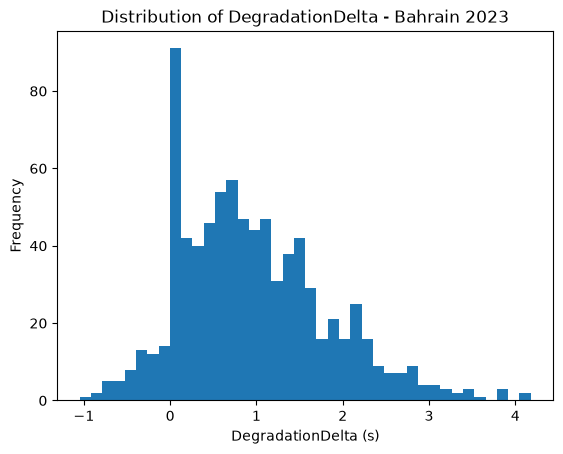

In [13]:
stint_key = finisher_laps["Driver"] + "_" + finisher_laps["Stint"].astype(str)
fresh = finisher_laps.assign(sk=stint_key).groupby("sk")["FuelCorrectedLapTime"].transform(
    lambda x: x.nsmallest(3).median()
)
finisher_laps["StintFreshPace"] = fresh.values
finisher_laps["DegradationDelta"] = finisher_laps["FuelCorrectedLapTime"] - finisher_laps["StintFreshPace"]
finisher_laps = finisher_laps.dropna(subset=["DegradationDelta"]).copy()
finisher_laps = finisher_laps[finisher_laps["DegradationDelta"].between(-3, 8)].copy()
print(finisher_laps[["Driver", "TyreLife", "FuelCorrectedLapTime", "StintFreshPace", "DegradationDelta"]].head(15))
plt.hist(finisher_laps["DegradationDelta"], bins=40)
plt.xlabel("DegradationDelta (s)")
plt.ylabel("Frequency")
plt.title("Distribution of DegradationDelta - Bahrain 2023")
plt.savefig("../figs/eda/degradationdelta_hist_bahrain.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.4 Fuel-corrected degradation plots per stint

In [14]:
for d in drivers:
    ds = finisher_laps[finisher_laps["Driver"] == d].Stint.unique()
    for s in ds:
        driver_stint = finisher_laps[(finisher_laps["Driver"] == d) & (finisher_laps["Stint"] == s)]
        compound = driver_stint["Compound"].iloc[0]
        plt.xlabel("Tyre Age")
        plt.ylabel("DegradationDelta (s)")
        plt.title(f"{d} Stint {s} {compound} Bahrain 2023 DegradationDelta by tyre age")
        plt.plot(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['DegradationDelta']))
        plt.scatter(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['DegradationDelta']))
        plt.axhline(0, color='red', linestyle='--', alpha=0.5)
        plt.savefig(f"../figs/degradation_corrected/bahrain2023_{d}_stint{s}_{compound}_degradation_delta.png")
        plt.cla()
plt.close()

### 3.5 Compound encoding (one-hot, drop HARD as reference)

In [15]:
finisher_laps = pd.get_dummies(finisher_laps, columns=["Compound"], drop_first=True)
print(finisher_laps.head())
print(finisher_laps.columns)

                    Time Driver DriverNumber                LapTime  \
2 0 days 01:07:31.882000    VER            1 0 days 00:01:38.006000   
3 0 days 01:09:09.858000    VER            1 0 days 00:01:37.976000   
4 0 days 01:10:47.893000    VER            1 0 days 00:01:38.035000   
5 0 days 01:12:25.879000    VER            1 0 days 00:01:37.986000   
6 0 days 01:14:03.900000    VER            1 0 days 00:01:38.021000   

   LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
2        3.0      1        NaT       NaT 0 days 00:00:31.388000   
3        4.0      1        NaT       NaT 0 days 00:00:31.271000   
4        5.0      1        NaT       NaT 0 days 00:00:31.244000   
5        6.0      1        NaT       NaT 0 days 00:00:31.341000   
6        7.0      1        NaT       NaT 0 days 00:00:31.290000   

             Sector2Time  ... DeletedReason FastF1Generated IsAccurate  \
2 0 days 00:00:42.469000  ...                         False       True   
3 0 days 00:00:42.6420

### 3.6 TyreLifeSquared

In [16]:
finisher_laps["TyreLifeSquared"] = finisher_laps["TyreLife"] ** 2
finisher_laps[["TyreLife", "TyreLifeSquared"]].head()

,TyreLife,TyreLifeSquared
2,6.0,36.0
3,7.0,49.0
4,8.0,64.0
5,9.0,81.0
6,10.0,100.0


### 3.7 Weather feature (track temperature)
Aligned to laps by nearest timestamp via `merge_asof`.

In [17]:
weather_data = bahrain2023_race.weather_data
print(weather_data)
print(bahrain2023_race.weather_data.columns)

                      Time  AirTemp  Humidity  Pressure  Rainfall  TrackTemp  \
0   0 days 00:00:45.438000     29.8      19.0    1016.5     False       35.1   
1   0 days 00:01:45.453000     29.7      19.0    1016.5     False       35.0   
2   0 days 00:02:45.452000     29.7      19.0    1016.5     False       34.9   
3   0 days 00:03:45.466000     29.6      19.0    1016.5     False       34.9   
4   0 days 00:04:45.449000     29.6      19.0    1016.5     False       34.8   
..                     ...      ...       ...       ...       ...        ...   
156 0 days 02:36:46.050000     26.3      21.0    1017.4     False       28.7   
157 0 days 02:37:46.064000     26.3      21.0    1017.4     False       28.7   
158 0 days 02:38:46.063000     26.3      21.0    1017.5     False       28.7   
159 0 days 02:39:46.109000     26.3      21.0    1017.4     False       28.7   
160 0 days 02:40:46.061000     26.2      21.0    1017.5     False       28.7   

     WindDirection  WindSpeed  
0      

In [18]:
laps_sorted = finisher_laps.sort_values("LapStartTime")
weather_sorted = weather_data.sort_values("Time")
merged = pd.merge_asof(laps_sorted, weather_sorted, left_on="LapStartTime", right_on="Time", direction="nearest")
print(merged.isna().sum())

Time_x                    0
Driver                    0
DriverNumber              0
LapTime                   0
LapNumber                 0
Stint                     0
PitOutTime              816
PitInTime               816
Sector1Time               0
Sector2Time               0
Sector3Time               0
Sector1SessionTime        3
Sector2SessionTime        0
Sector3SessionTime        0
SpeedI1                   0
SpeedI2                   0
SpeedFL                   0
SpeedST                   0
IsPersonalBest            0
TyreLife                  0
FreshTyre                 0
Team                      0
LapStartTime              0
LapStartDate              0
TrackStatus               0
Position                  0
Deleted                   0
DeletedReason             0
FastF1Generated           0
IsAccurate                0
LapTimeSeconds            0
FuelMass                  0
FuelCorrectedLapTime      0
StintFreshPace            0
DegradationDelta          0
Compound_MEDIUM     

## Phase 4: Generalising across races
All single-race steps consolidated into `race_analysis`. Updated additions: `TrackStatus == '1'` filter, `StintFreshPace`, and `DegradationDelta`.

In [19]:
def race_analysis(gp, year, plot=True):

    race = fastf1.get_session(year, gp, "R")
    race.load()
    laps = race.laps
    results = race.results
    weather_data = race.weather_data

    laps["LapTimeSeconds"] = laps["LapTime"].dt.total_seconds()
    laps["Stint"] = laps["Stint"].astype(int)
    clean_laps = laps[laps["IsAccurate"] == True].copy()
    clean_laps = clean_laps[clean_laps["TrackStatus"].astype(str) == "1"].copy()

    print(f"=== {gp} {year} ===")

    finisher_abbrevs = results[results["Status"].isin(["Finished", "Lapped"])]["Abbreviation"].tolist()
    finisher_laps = clean_laps[clean_laps["Driver"].isin(finisher_abbrevs)].copy()
    drivers = finisher_laps["Driver"].unique()
    print(f"All drivers: {clean_laps['Driver'].nunique()}, finishers: {finisher_laps['Driver'].nunique()}")
    print(f"Dropped (retired): {set(clean_laps['Driver'].unique()) - set(finisher_abbrevs)}")

    START_FUEL = 109.0
    RACE_LAPS = clean_laps["LapNumber"].max()
    FUEL_BURN = START_FUEL / RACE_LAPS
    finisher_laps["FuelMass"] = (START_FUEL - FUEL_BURN * finisher_laps["LapNumber"]).clip(lower=0.0)

    sec_per_kg_fuel = []
    for d in drivers:
        driver_laps = finisher_laps[finisher_laps["Driver"] == d].copy()
        y = driver_laps["LapTimeSeconds"]
        X = driver_laps[["TyreLife", "FuelMass"]]
        laptime_predictor = LinearRegression()
        laptime_predictor.fit(X, y)
        sec_per_kg_fuel.append(laptime_predictor.coef_[1])
    gamma = np.mean(sec_per_kg_fuel)
    per_lap_gain = gamma * FUEL_BURN
    race_cum_gain = per_lap_gain * RACE_LAPS
    print(f"Gamma: {gamma:.4f} s/kg")
    print(f"Per-lap gain: {per_lap_gain:.4f} s")
    print(f"Race-total gain: {race_cum_gain:.2f} s")

    if plot:
        for d in drivers:
            ds = finisher_laps[finisher_laps["Driver"] == d].Stint.unique()
            for s in ds:
                driver_stint = finisher_laps[(finisher_laps["Driver"] == d) & (finisher_laps["Stint"] == s)]
                compound = driver_stint["Compound"].iloc[0]
                plt.xlabel("Tyre Age")
                plt.ylabel("Lap Time")
                plt.title(f"{d} Stint {s} Compound: {compound} {gp} {year} laptime evolution (Lower is faster)")
                plt.plot(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['LapTimeSeconds']))
                plt.scatter(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['LapTimeSeconds']))
                plt.savefig(f"../figs/screening/{gp}{year}_{d}_stint{s}_{compound}_tyredeg_evo_scatter.png")
                plt.cla()
        plt.close()

    finisher_laps["FuelCorrectedLapTime"] = finisher_laps["LapTimeSeconds"] - gamma * finisher_laps["FuelMass"]

    stint_key = finisher_laps["Driver"] + "_" + finisher_laps["Stint"].astype(str)
    fresh = finisher_laps.assign(sk=stint_key).groupby("sk")["FuelCorrectedLapTime"].transform(
        lambda x: x.nsmallest(3).median()
    )
    finisher_laps["StintFreshPace"] = fresh.values
    finisher_laps["DegradationDelta"] = finisher_laps["FuelCorrectedLapTime"] - finisher_laps["StintFreshPace"]

    if plot:
        for d in drivers:
            ds = finisher_laps[finisher_laps["Driver"] == d].Stint.unique()
            for s in ds:
                driver_stint = finisher_laps[(finisher_laps["Driver"] == d) & (finisher_laps["Stint"] == s)]
                compound = driver_stint["Compound"].iloc[0]
                plt.xlabel("Tyre Age")
                plt.ylabel("DegradationDelta (s)")
                plt.title(f"{d} Stint {s} {compound} {gp} {year} DegradationDelta by tyre age")
                plt.plot(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['DegradationDelta']))
                plt.scatter(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['DegradationDelta']))
                plt.axhline(0, color='red', linestyle='--', alpha=0.5)
                plt.savefig(f"../figs/screening/{gp}{year}_{d}_stint{s}_{compound}_degradation_delta.png")
                plt.cla()
        plt.close()

    laps_sorted = finisher_laps.sort_values("LapStartTime")
    weather_sorted = weather_data.sort_values("Time")
    finisher_laps = pd.merge_asof(laps_sorted, weather_sorted, left_on="LapStartTime", right_on="Time", direction="nearest")

    finisher_laps["TyreLifeSquared"] = finisher_laps["TyreLife"] ** 2

    return finisher_laps, gamma

### 4.1 Multi-race screening and dataset creation (with rate-limit handling)

In [20]:
"""logging.getLogger('fastf1').setLevel(logging.WARNING)
CALLS_PER_RACE_EST = 6
CALLS_CAP = 490
SLEEP_BUFFER_MIN = 5
GAMMA_MIN, GAMMA_MAX = 0.015, 0.06
MAX_RAIN_FRACTION = 0.10
MIN_FINISHERS = 8
YEARS = [2022, 2023, 2024, 2025]
PROGRESS_FILE = "screen_progress.json"

progress = json.load(open(PROGRESS_FILE)) if os.path.exists(PROGRESS_FILE) else {}
ok_frames = []
calls = 0

for year in YEARS:
    try:
        schedule = fastf1.get_event_schedule(year)
    except Exception:
        continue

    for i, event in schedule.iterrows():
        if event.get("RoundNumber", 0) < 1:
            continue
        gp = event["EventName"]
        k = f"{year}|{gp}"

        if calls + CALLS_PER_RACE_EST > CALLS_CAP:
            now = dt.datetime.now()
            nxt = (now + dt.timedelta(hours=1)).replace(minute=0, second=0, microsecond=0)
            time.sleep((nxt - now).total_seconds() + SLEEP_BUFFER_MIN * 60)
            calls = 0

        if k in progress and progress[k]["verdict"] == "DROP":
            continue

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                laps_df, gamma = race_analysis(gp, year, plot=False)
            calls += CALLS_PER_RACE_EST
        except Exception as e:
            if "RateLimit" in type(e).__name__:
                now = dt.datetime.now()
                nxt = (now + dt.timedelta(hours=1)).replace(minute=0, second=0, microsecond=0)
                time.sleep((nxt - now).total_seconds() + SLEEP_BUFFER_MIN * 60)
                calls = 0
                continue
            progress[k] = {"verdict": "DROP", "reason": f"error: {type(e).__name__}", "n_finishers": None, "rain_fraction": None, "gamma": None, "year": year, "gp": gp}
            continue

        n = laps_df["Driver"].nunique()
        rf = float(laps_df["Rainfall"].mean()) if "Rainfall" in laps_df.columns else 0.0
        verdict, reason = "DROP", ""
        if n < MIN_FINISHERS:
            reason = f"too few finishers ({n})"
        elif rf > MAX_RAIN_FRACTION:
            reason = f"too wet ({rf:.2f})"
        elif not (GAMMA_MIN <= gamma <= GAMMA_MAX):
            reason = f"non-physical gamma ({gamma:.4f})"
        else:
            verdict, reason = "OK", "passed"

        progress[k] = {"verdict": verdict, "reason": reason, "n_finishers": int(n), "rain_fraction": rf, "gamma": float(gamma), "year": year, "gp": gp}

        if verdict == "OK":
            laps_df = laps_df.copy()
            laps_df["Race"] = f"{year}_{gp}"
            ok_frames.append(laps_df)

    json.dump(progress, open(PROGRESS_FILE, "w"), indent=1)

all_laps = pd.concat(ok_frames, ignore_index=True)
team_map = {
    "AlphaTauri": "RB",
    "Racing Bulls": "RB",
    "Alfa Romeo": "Kick Sauber",
}
all_laps["Team"] = all_laps["Team"].replace(team_map)
all_laps = pd.get_dummies(all_laps, columns=["Compound"], drop_first=True)

print("all_laps shape:", all_laps.shape)
print("\nraces:", all_laps["Race"].nunique())
print(all_laps["Race"].value_counts())
print("\ncolumns:", list(all_laps.columns))"""

'logging.getLogger(\'fastf1\').setLevel(logging.WARNING)\nCALLS_PER_RACE_EST = 6\nCALLS_CAP = 490\nSLEEP_BUFFER_MIN = 5\nGAMMA_MIN, GAMMA_MAX = 0.015, 0.06\nMAX_RAIN_FRACTION = 0.10\nMIN_FINISHERS = 8\nYEARS = [2022, 2023, 2024, 2025]\nPROGRESS_FILE = "screen_progress.json"\n\nprogress = json.load(open(PROGRESS_FILE)) if os.path.exists(PROGRESS_FILE) else {}\nok_frames = []\ncalls = 0\n\nfor year in YEARS:\n    try:\n        schedule = fastf1.get_event_schedule(year)\n    except Exception:\n        continue\n\n    for i, event in schedule.iterrows():\n        if event.get("RoundNumber", 0) < 1:\n            continue\n        gp = event["EventName"]\n        k = f"{year}|{gp}"\n\n        if calls + CALLS_PER_RACE_EST > CALLS_CAP:\n            now = dt.datetime.now()\n            nxt = (now + dt.timedelta(hours=1)).replace(minute=0, second=0, microsecond=0)\n            time.sleep((nxt - now).total_seconds() + SLEEP_BUFFER_MIN * 60)\n            calls = 0\n\n        if k in progress and 

In [21]:
# all_laps.to_csv("../data/all_laps.csv", index=False)

## Phase 5: Modelling
**Target: `DegradationDelta` (s).** Fuel-corrected lap time minus the stint's fresh-tyre pace. Captures only degradation, removing circuit identity and car pace. Features: TyreLife, TyreLifeSquared, Compound (one-hot), TrackTemp, Team (one-hot). Team is included because top teams have demonstrably lower degradation rates (Red Bull, McLaren, Ferrari) vs. backmarkers (Kick Sauber, Haas), a constructors effect not absorbed by StintFreshPace (which normalises pace level, not degradation slope). In practice Team adds negligible MAE improvement (~0.0002 s) but produces interpretable coefficients that validate the model physically.

### 5.1 Load data, compute DegradationDelta, train/test split by race

In [22]:
all_laps = pd.read_csv("../data/all_laps.csv")

all_laps = all_laps[all_laps["TrackStatus"].astype(str) == "1"].copy()

stint_key = all_laps["Driver"] + "_" + all_laps["Race"] + "_" + all_laps["Stint"].astype(str)
all_laps["StintFreshPace"] = all_laps.assign(sk=stint_key).groupby("sk")["FuelCorrectedLapTime"].transform(
    lambda x: x.nsmallest(3).median()
)
all_laps["DegradationDelta"] = all_laps["FuelCorrectedLapTime"] - all_laps["StintFreshPace"]
all_laps = all_laps.dropna(subset=["DegradationDelta"]).copy()
all_laps = all_laps[all_laps["DegradationDelta"].between(-3, 8)].copy()

mask = all_laps["Race"].str.contains("Spanish|Japanese|United States|Mexico|Hungarian")
test = all_laps[mask]
train = all_laps[~mask]
print(test["Race"].unique())
print(train["Race"].unique())

['2022_Spanish Grand Prix' '2022_United States Grand Prix'
 '2023_Spanish Grand Prix' '2023_Hungarian Grand Prix'
 '2023_Japanese Grand Prix' '2023_United States Grand Prix'
 '2024_Japanese Grand Prix' '2024_Spanish Grand Prix'
 '2024_Hungarian Grand Prix' '2024_United States Grand Prix'
 '2024_Mexico City Grand Prix' '2025_Japanese Grand Prix'
 '2025_Spanish Grand Prix' '2025_Hungarian Grand Prix'
 '2025_United States Grand Prix' '2025_Mexico City Grand Prix']
['2022_Bahrain Grand Prix' '2022_Saudi Arabian Grand Prix'
 '2022_Australian Grand Prix' '2022_Miami Grand Prix'
 '2022_Azerbaijan Grand Prix' '2022_Canadian Grand Prix'
 '2022_French Grand Prix' '2022_Belgian Grand Prix'
 '2022_Dutch Grand Prix' '2022_Italian Grand Prix'
 '2022_São Paulo Grand Prix' '2022_Abu Dhabi Grand Prix'
 '2023_Bahrain Grand Prix' '2023_Saudi Arabian Grand Prix'
 '2023_Azerbaijan Grand Prix' '2023_Miami Grand Prix'
 '2023_Austrian Grand Prix' '2023_British Grand Prix'
 '2023_Italian Grand Prix' '2023_Qata

### 5.1b Feature correlation overview
Correlation among the key numeric quantities on the training set: the TyreLife and FuelMass collinearity that motivated fuel correction, the near-zero TyreLife to raw lap-time link (degradation masked by fuel), and the positive TyreLife to DegradationDelta link (the signal recovered by the corrected target).

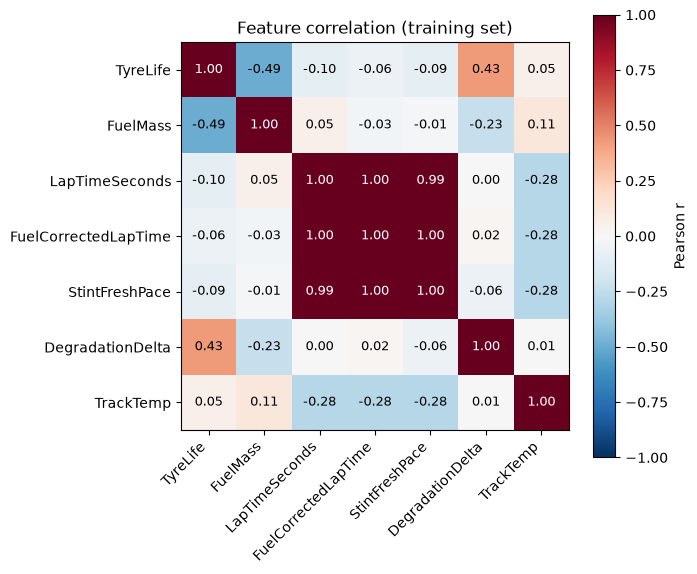

In [23]:
corr_cols = [c for c in ["TyreLife", "FuelMass", "LapTimeSeconds", "FuelCorrectedLapTime",
                          "StintFreshPace", "DegradationDelta", "TrackTemp"] if c in train.columns]
corr = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.55 else "black", fontsize=9)
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Feature correlation (training set)")
plt.tight_layout()
plt.savefig("../figs/data/feature_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.1c Dataset composition (held-out circuits)
Lap counts per race, coloured by the train/test split. The five test circuits (all years) are held out entirely, so each race is wholly train or wholly test and the evaluation measures generalisation to unseen tracks.

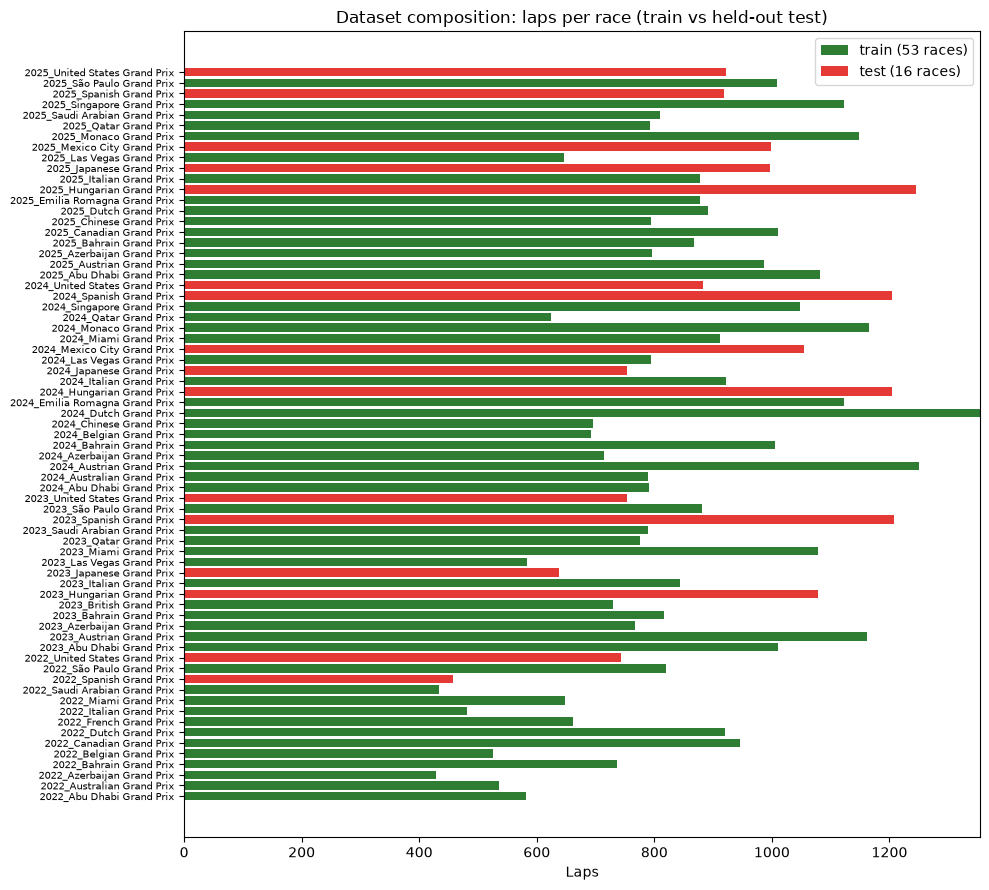

In [24]:
train_counts = train["Race"].value_counts()
test_counts = test["Race"].value_counts()
all_races = sorted(set(train_counts.index) | set(test_counts.index))
tr = [train_counts.get(r, 0) for r in all_races]
te = [test_counts.get(r, 0) for r in all_races]

fig, ax = plt.subplots(figsize=(10, 9))
y = np.arange(len(all_races))
ax.barh(y, tr, color="#2E7D32", label=f"train ({len(train_counts)} races)")
ax.barh(y, te, left=tr, color="#E53935", label=f"test ({len(test_counts)} races)")
ax.set_yticks(y); ax.set_yticklabels(all_races, fontsize=7)
ax.set_xlabel("Laps"); ax.set_title("Dataset composition: laps per race (train vs held-out test)")
ax.legend()
plt.tight_layout()
plt.savefig("../figs/data/dataset_composition.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.2 Feature and target setup

In [25]:
team_cols = [c for c in all_laps.columns if c.startswith("Team_")]
features = ["TyreLife", "TyreLifeSquared", "Compound_MEDIUM", "Compound_SOFT", "TrackTemp"] + team_cols
X_train = train[features]
y_train = train["DegradationDelta"]
X_test = test[features]
y_test = test["DegradationDelta"]
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_train.isna().sum())

(44740, 14) (44740,)
(15056, 14) (15056,)
TyreLife                0
TyreLifeSquared         0
Compound_MEDIUM         0
Compound_SOFT           0
TrackTemp               0
Team_Aston Martin       0
Team_Ferrari            0
Team_Haas F1 Team       0
Team_Kick Sauber        0
Team_McLaren            0
Team_Mercedes           0
Team_RB                 0
Team_Red Bull Racing    0
Team_Williams           0
dtype: int64


### 5.3 Baseline (predict training mean)

In [26]:
baseline_pred = np.full(len(y_test), y_train.mean())
mae_baseline = mean_absolute_error(y_test, baseline_pred)
rmse_baseline = root_mean_squared_error(y_test, baseline_pred)
print("Baseline MAE: ", mae_baseline)
print("Baseline RMSE: ", rmse_baseline)

Baseline MAE:  0.6375519665320539
Baseline RMSE:  0.8593390098342438


### 5.4 Model 1: Linear Regression

In [27]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
lr_predictions = model_lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, lr_predictions)
rmse_lr = root_mean_squared_error(y_test, lr_predictions)
mae_lr_train = mean_absolute_error(y_train, model_lr.predict(X_train))
coeffs_lr = dict(zip(features, model_lr.coef_))
print("Linear Regression MAE: ", mae_lr)
print("Linear Regression RMSE: ", rmse_lr)
print("Coefficients:", coeffs_lr)
print("Intercept:", model_lr.intercept_)

Linear Regression MAE:  0.5342019571023117
Linear Regression RMSE:  0.7486890946738096
Coefficients: {'TyreLife': np.float64(0.050567674987282714), 'TyreLifeSquared': np.float64(-0.00033416470564193293), 'Compound_MEDIUM': np.float64(0.01585620434629207), 'Compound_SOFT': np.float64(0.08980634662218956), 'TrackTemp': np.float64(-0.0007650852760880172), 'Team_Aston Martin': np.float64(-0.08687941535550396), 'Team_Ferrari': np.float64(-0.11450742876757944), 'Team_Haas F1 Team': np.float64(0.04159666876943298), 'Team_Kick Sauber': np.float64(0.12220818195037876), 'Team_McLaren': np.float64(-0.10852303270627695), 'Team_Mercedes': np.float64(-0.18443097908755934), 'Team_RB': np.float64(-0.01834372788863821), 'Team_Red Bull Racing': np.float64(-0.12440675207529901), 'Team_Williams': np.float64(-0.0428236379494584)}
Intercept: 0.2590367014006997


### 5.5 Model 2: Decision Tree

In [28]:
depths = [3, 5, 7, 10, 15, None]
groups = train["Race"]
gkf = GroupKFold(n_splits=5)
for d in depths:
    model_dt = DecisionTreeRegressor(random_state=42, max_depth=d)
    model_dt.fit(X_train, y_train)
    dt_predictions = model_dt.predict(X_test)
    dt_predictions_train = model_dt.predict(X_train)
    mae_dt = mean_absolute_error(y_test, dt_predictions)
    mae_dt_train = mean_absolute_error(y_train, dt_predictions_train)
    rmse_dt = root_mean_squared_error(y_test, dt_predictions)
    rmse_dt_train = root_mean_squared_error(y_train, dt_predictions_train)
    print("MAE test: ", (d, mae_dt))
    print("MAE train: ", (d, mae_dt_train))
    print("RMSE test: ", (d, rmse_dt))
    print("RMSE train: ", (d, rmse_dt_train))
    scores = cross_val_score(model_dt, X_train, y_train, groups=groups, cv=gkf, scoring="neg_mean_absolute_error")
    print("Group K-fold cross-validated MAE: ", (d, np.mean(-scores)))

MAE test:  (3, 0.537068534433606)
MAE train:  (3, 0.5484199179261329)
RMSE test:  (3, 0.7566513552012808)
RMSE train:  (3, 0.7771832212992489)
Group K-fold cross-validated MAE:  (3, np.float64(0.5593380465860083))
MAE test:  (5, 0.5394679159689975)
MAE train:  (5, 0.539237084435237)
RMSE test:  (5, 0.7600195655814905)
RMSE train:  (5, 0.7626886261614014)
Group K-fold cross-validated MAE:  (5, np.float64(0.5700305716927498))
MAE test:  (7, 0.5546062886130338)
MAE train:  (7, 0.5203645704572875)
RMSE test:  (7, 0.7811623058023777)
RMSE train:  (7, 0.7368976418382388)
Group K-fold cross-validated MAE:  (7, np.float64(0.579301318920054))
MAE test:  (10, 0.5836563238464493)
MAE train:  (10, 0.48352136724675293)
RMSE test:  (10, 0.8222980869791777)
RMSE train:  (10, 0.6877531935551547)
Group K-fold cross-validated MAE:  (10, np.float64(0.607930561359335))
MAE test:  (15, 0.6523168074805831)
MAE train:  (15, 0.3652012399860064)
RMSE test:  (15, 0.938250837412148)
RMSE train:  (15, 0.554142573

In [29]:
model_dt = DecisionTreeRegressor(max_depth=3, random_state=42)
model_dt.fit(X_train, y_train)
mae_dt = mean_absolute_error(y_test, model_dt.predict(X_test))
mae_dt_train = mean_absolute_error(y_train, model_dt.predict(X_train))
scores = cross_val_score(model_dt, X_train, y_train, groups=train["Race"], cv=GroupKFold(n_splits=5), scoring="neg_mean_absolute_error")
print("Final tree (d=3) test MAE:", mae_dt, "train MAE:", mae_dt_train, "CV MAE:", -scores.mean())

Final tree (d=3) test MAE: 0.537068534433606 train MAE: 0.5484199179261329 CV MAE: 0.5593380465860083


### 5.6 Model 3: Random Forest

In [30]:
groups = train["Race"]
gkf = GroupKFold(n_splits=5)
model_rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
rf_predictions = model_rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, rf_predictions)
mae_rf_train = mean_absolute_error(y_train, model_rf.predict(X_train))
rmse_rf = root_mean_squared_error(y_test, rf_predictions)
print("MAE test: ", mae_rf)
print("MAE train: ", mae_rf_train)
print("RMSE test: ", rmse_rf)
scores = cross_val_score(model_rf, X_train, y_train, groups=groups, cv=gkf, scoring="neg_mean_absolute_error")
print("Group K-fold cross-validated MAE: ", np.mean(-scores))

MAE test:  0.63623380961098
MAE train:  0.21875868064954657
RMSE test:  0.870705070075122
Group K-fold cross-validated MAE:  0.6509538598287141


### 5.7 Model 4: XGBoost

In [31]:
groups = train["Race"]
gkf = GroupKFold(n_splits=5)

model_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
model_xgb.fit(X_train, y_train)

xgb_pred = model_xgb.predict(X_test)
xgb_pred_train = model_xgb.predict(X_train)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
mae_xgb_train = mean_absolute_error(y_train, xgb_pred_train)
rmse_xgb = root_mean_squared_error(y_test, xgb_pred)

print("XGB MAE  test/train:", mae_xgb, mae_xgb_train)
print("XGB RMSE test/train:", rmse_xgb)

scores = cross_val_score(model_xgb, X_train, y_train,
                         groups=groups, cv=gkf, scoring="neg_mean_absolute_error")
print("XGB GroupKFold MAE:", -scores.mean())

XGB MAE  test/train: 0.565306652366353 0.5027559038841285
XGB RMSE test/train: 0.7751740590878284
XGB GroupKFold MAE: 0.5707384516453385


## Phase 6: Evaluation
The correct scale-robust metric is margin over the same-target baseline. Baseline predicts the training mean DegradationDelta for every test lap; a real model must beat this to demonstrate signal extraction.

Linear Regression achieves **16% margin over baseline** (0.64 -> 0.53 s MAE). The complexity models (RF, XGBoost) are not consistently better and show more overfitting, confirming that degradation is a low-complexity signal once the correct target is used. Note: do not compare these numbers to the 7.45 s in the absolute-lap-time version; the targets differ in scale and in what variance they contain, so the comparison is not meaningful.

### 6.1 Model comparison

In [32]:
rows = [["Baseline (mean)",
         mean_absolute_error(y_test, np.full(len(y_test), y_train.mean())),
         root_mean_squared_error(y_test, np.full(len(y_test), y_train.mean())),
         mean_absolute_error(y_train, np.full(len(y_train), y_train.mean()))]]
for name, m in [("Linear Regression", model_lr),
                ("Decision Tree (d=3)", model_dt),
                ("Random Forest (200)", model_rf),
                ("XGBoost (300)", model_xgb)]:
    rows.append([name,
                 mean_absolute_error(y_test, m.predict(X_test).ravel()),
                 root_mean_squared_error(y_test, m.predict(X_test).ravel()),
                 mean_absolute_error(y_train, m.predict(X_train).ravel())])

comparison = pd.DataFrame(rows, columns=["Model", "Test MAE", "Test RMSE", "Train MAE"]).set_index("Model")
print(comparison.round(3).to_string())

                     Test MAE  Test RMSE  Train MAE
Model                                              
Baseline (mean)         0.638      0.859      0.633
Linear Regression       0.534      0.749      0.545
Decision Tree (d=3)     0.537      0.757      0.548
Random Forest (200)     0.636      0.871      0.219
XGBoost (300)           0.565      0.775      0.503


### 6.2 Per-circuit analysis and coefficient inspection
With `DegradationDelta` as target, the circuit offset is designed-out structurally. Per-circuit MAE should be small and the bias (mean residual) near zero for all circuits. We also inspect the linear regression coefficients. Expected signs: TyreLife positive (degradation increases with age); Soft > Medium > Hard (0, reference); top-team coefficients negative (lower degradation rate); backmarker teams positive. TyreLifeSquared is slightly negative, indicating a mildly concave degradation curve consistent with modern tyre management where drivers nurse high-age sets.

In [33]:
analysis = pd.DataFrame({
    "Race": test["Race"].values,
    "Compound_SOFT": test["Compound_SOFT"].values,
    "Compound_MEDIUM": test["Compound_MEDIUM"].values,
    "y_true": y_test.values,
    "y_pred": model_lr.predict(X_test),
})
analysis["resid"] = analysis["y_true"] - analysis["y_pred"]

per_circuit = analysis.groupby("Race")["resid"].apply(lambda r: r.abs().mean()).rename("MAE")
per_circuit_bias = analysis.groupby("Race")["resid"].mean().rename("bias")
print(pd.concat([per_circuit, per_circuit_bias], axis=1).round(3).to_string())
print()
print("Overall test MAE:", round(analysis["resid"].abs().mean(), 3))

print("\nLinear regression coefficients (DegradationDelta model):")
for feat, coef in zip(features, model_lr.coef_):
    print(f"  {feat:20s}: {coef:.4f}")
print(f"  {'intercept':20s}: {model_lr.intercept_:.4f}")

                                 MAE   bias
Race                                       
2022_Spanish Grand Prix        0.656  0.383
2022_United States Grand Prix  0.493 -0.078
2023_Hungarian Grand Prix      0.492  0.018
2023_Japanese Grand Prix       0.571  0.237
2023_Spanish Grand Prix        0.497  0.098
2023_United States Grand Prix  0.465  0.104
2024_Hungarian Grand Prix      0.607  0.321
2024_Japanese Grand Prix       0.895  0.699
2024_Mexico City Grand Prix    0.507 -0.141
2024_Spanish Grand Prix        0.548  0.261
2024_United States Grand Prix  0.502 -0.195
2025_Hungarian Grand Prix      0.589  0.140
2025_Japanese Grand Prix       0.411 -0.238
2025_Mexico City Grand Prix    0.430  0.026
2025_Spanish Grand Prix        0.527  0.103
2025_United States Grand Prix  0.470 -0.056

Overall test MAE: 0.534

Linear regression coefficients (DegradationDelta model):
  TyreLife            : 0.0506
  TyreLifeSquared     : -0.0003
  Compound_MEDIUM     : 0.0159
  Compound_SOFT       : 0.0898


### 6.3 Calibration diagnostics
A model can have good average MAE yet be systematically wrong in specific conditions. Four checks: (1) mean residual by TyreLife bin, (2) actual vs predicted scatter, (3) residual histogram, (4) per-compound bias. A well-calibrated model has near-zero bias in every subgroup and a residual distribution centred at zero.

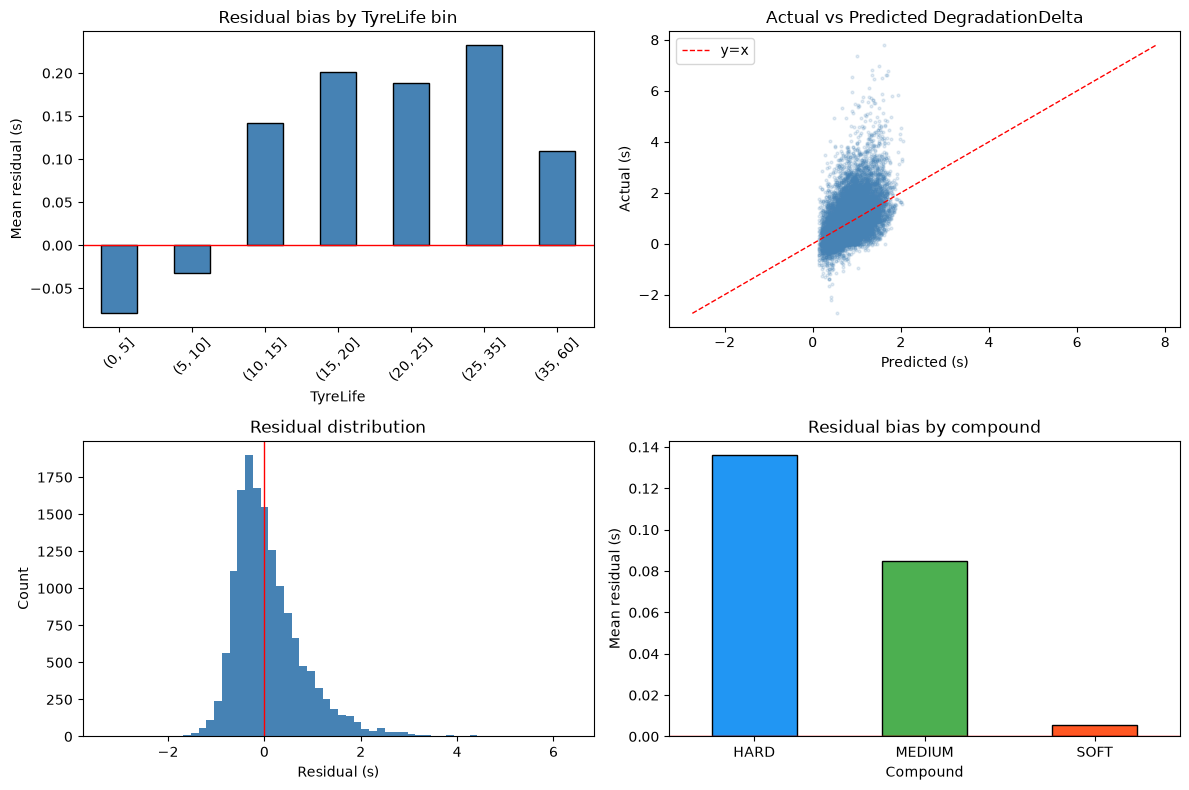

Calibration summary:
  Global bias      : 0.0928 s
  Global std       : 0.7429 s
  Actual~pred slope: 1.2604

Per-compound bias:
                 bias    MAE
compound_label              
HARD            0.136  0.590
MEDIUM          0.085  0.478
SOFT            0.005  0.522

Bias by TyreLife bin:
           bias    MAE
tl_bin                
(0, 5]   -0.079  0.440
(5, 10]  -0.032  0.436
(10, 15]  0.142  0.528
(15, 20]  0.201  0.587
(20, 25]  0.188  0.614
(25, 35]  0.233  0.695
(35, 60]  0.109  0.734


In [34]:
resid_te = y_test - model_lr.predict(X_test)
pred_te  = model_lr.predict(X_test)

test_diag = test.copy()
test_diag['resid'] = resid_te.values
test_diag['pred']  = pred_te
test_diag['compound_label'] = 'HARD'
test_diag.loc[test_diag['Compound_MEDIUM'].astype(bool), 'compound_label'] = 'MEDIUM'
test_diag.loc[test_diag['Compound_SOFT'].astype(bool),   'compound_label'] = 'SOFT'

bins = [0, 5, 10, 15, 20, 25, 35, 60]
test_diag['tl_bin'] = pd.cut(test_diag['TyreLife'], bins=bins)
bin_bias = test_diag.groupby('tl_bin', observed=True)['resid'].mean()
bin_mae  = test_diag.groupby('tl_bin', observed=True)['resid'].apply(lambda x: x.abs().mean())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
bin_bias.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.axhline(0, color='red', linewidth=1)
ax.set_title('Residual bias by TyreLife bin')
ax.set_xlabel('TyreLife'); ax.set_ylabel('Mean residual (s)')
ax.tick_params(axis='x', rotation=45)

ax = axes[0, 1]
ax.scatter(pred_te, y_test.values, alpha=0.15, s=4, color='steelblue')
lo, hi = min(pred_te.min(), y_test.min()), max(pred_te.max(), y_test.max())
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1, label='y=x')
ax.set_title('Actual vs Predicted DegradationDelta')
ax.set_xlabel('Predicted (s)'); ax.set_ylabel('Actual (s)')
ax.legend()

ax = axes[1, 0]
ax.hist(resid_te, bins=60, color='steelblue', edgecolor='none')
ax.axvline(0, color='red', linewidth=1)
ax.set_title('Residual distribution')
ax.set_xlabel('Residual (s)'); ax.set_ylabel('Count')

ax = axes[1, 1]
comp_stats = test_diag.groupby('compound_label')['resid'].agg(
    bias='mean', MAE=lambda x: x.abs().mean()
)
comp_stats['bias'].plot(kind='bar', ax=ax, color=['#2196F3','#4CAF50','#FF5722'], edgecolor='black')
ax.axhline(0, color='red', linewidth=1)
ax.set_title('Residual bias by compound')
ax.set_xlabel('Compound'); ax.set_ylabel('Mean residual (s)')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../figs/model/calibration_diagnostics.png', dpi=120)
plt.show()

print('Calibration summary:')
print(f'  Global bias      : {resid_te.mean():.4f} s')
print(f'  Global std       : {resid_te.std():.4f} s')
print(f'  Actual~pred slope: {LinearRegression().fit(pred_te.reshape(-1,1), y_test).coef_[0]:.4f}')
print()
print('Per-compound bias:')
print(comp_stats.round(3))
print()
print('Bias by TyreLife bin:')
print(pd.concat([bin_bias.rename('bias'), bin_mae.rename('MAE')], axis=1).round(3))

**Calibration findings.** The global bias is +0.09 s: the model slightly under-predicts degradation on average. More importantly, the bias increases with tyre age (near-zero at TyreLife 0-10, rises to +0.23 s at TyreLife 25-35), meaning the model underestimates late-stint cliff degradation. HARD compound is the most biased (+0.14 s); SOFT is best calibrated (+0.005 s). The actual-vs-predicted slope is ~1.26: the model is underconfident at the extremes (high actual degradation is even higher than predicted). These biases are acceptable for a linear model and a course project, but imply the MDP will recommend pitting slightly later than optimal on very old tyres or hard compounds.

### 6.4 Degradation curve: actual data vs model fit by compound
The single most important plot for a degradation model: how does `DegradationDelta` evolve with tyre age, per compound, and does the model capture it? Grey ribbons are the data mean ± 1 SD across all train stints at that TyreLife. Dashed lines are model predictions at the mean TrackTemp (no team adjustment). Ordering should be SOFT fastest degrading, HARD slowest; a warm-up dip at TyreLife 1-3 is expected from the StintFreshPace construction.

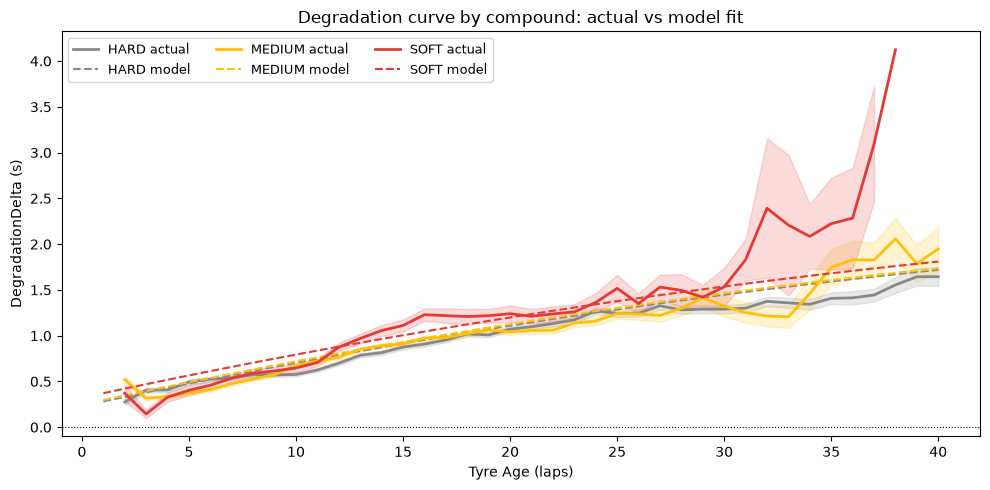

In [35]:
mean_track_temp = float(train['TrackTemp'].mean())
tl_range = np.arange(1, 41, dtype=float)
compound_specs = [('HARD',0,0,'#888888'), ('MEDIUM',1,0,'#FFC107'), ('SOFT',0,1,'#E53935')]

train_plot = train.copy()
train_plot['comp_label'] = 'HARD'
train_plot.loc[train_plot['Compound_MEDIUM'].astype(bool), 'comp_label'] = 'MEDIUM'
train_plot.loc[train_plot['Compound_SOFT'].astype(bool),   'comp_label'] = 'SOFT'

fig, ax = plt.subplots(figsize=(10, 5))
for label, cm, cs, col in compound_specs:
    sub = train_plot[(train_plot['comp_label']==label) & (train_plot['TyreLife']<=40)]
    grouped = sub.groupby('TyreLife')['DegradationDelta']
    actual_mean = grouped.mean()
    actual_std  = grouped.std()
    actual_n    = grouped.count()
    se = actual_std / np.sqrt(actual_n)
    ax.fill_between(actual_mean.index,
                    actual_mean - se, actual_mean + se,
                    alpha=0.18, color=col)
    ax.plot(actual_mean.index, actual_mean.values,
            color=col, linewidth=2, label=f'{label} actual')
    X_pred = pd.DataFrame({
        f: ([0.0]*len(tl_range)) for f in features
    })
    X_pred['TyreLife']         = tl_range
    X_pred['TyreLifeSquared']  = tl_range**2
    X_pred['Compound_MEDIUM']  = cm
    X_pred['Compound_SOFT']    = cs
    X_pred['TrackTemp']        = mean_track_temp
    pred_vals = model_lr.predict(X_pred)
    ax.plot(tl_range, pred_vals,
            color=col, linewidth=1.5, linestyle='--', label=f'{label} model')

ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Tyre Age (laps)')
ax.set_ylabel('DegradationDelta (s)')
ax.set_title('Degradation curve by compound: actual vs model fit')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig('../figs/model/degradation_curve_by_compound.png', dpi=120)
plt.show()

**Degradation curve findings.** All three compounds show a warmup dip at TyreLife 1-5 (DegDelta goes slightly negative because those laps can occasionally be faster than the 3-lap median anchor). SOFT degrades fastest from TyreLife 10+ onwards. HARD and MEDIUM are nearly indistinguishable up to TyreLife 20, after which HARD shows higher variance (long stints push the curve). The model tracks the mean well for SOFT and MEDIUM but slightly underestimates the late-stint rise for HARD, consistent with the +0.14 s HARD bias seen in 6.3.

### 6.5 Feature importance (scaled coefficient magnitudes)
Each coefficient is multiplied by the standard deviation of its feature to put all on a common scale (contribution in seconds per 1-SD change). This reveals which features actually drive the prediction - TyreLife dominates; Team effects are real but small.

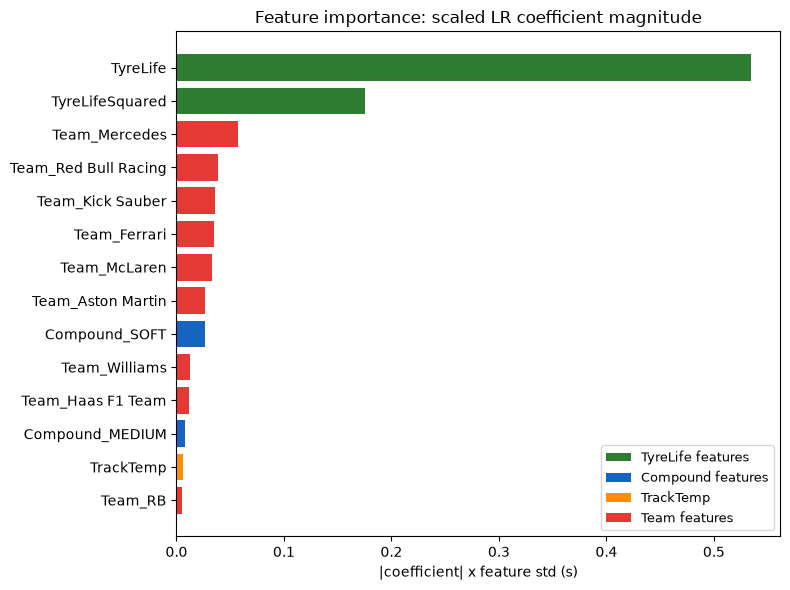

In [36]:
feat_stds = X_train.std()
scaled_coefs = pd.Series(np.abs(model_lr.coef_ * feat_stds.values), index=features)
scaled_coefs = scaled_coefs.sort_values(ascending=True)

colors = ['#E53935' if 'Team' in f else
          '#1565C0' if 'Compound' in f else
          '#2E7D32' if f.startswith('Tyre') else '#FF8F00'
          for f in scaled_coefs.index]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(scaled_coefs.index, scaled_coefs.values, color=colors, edgecolor='none')
ax.set_xlabel('|coefficient| x feature std (s)')
ax.set_title('Feature importance: scaled LR coefficient magnitude')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E7D32', label='TyreLife features'),
    Patch(facecolor='#1565C0', label='Compound features'),
    Patch(facecolor='#FF8F00', label='TrackTemp'),
    Patch(facecolor='#E53935', label='Team features'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../figs/model/feature_importance.png', dpi=120)
plt.show()

## Phase 7: Pit Decision (MDP framing)
The pit decision is a sequential decision under uncertainty. We frame it as an MDP (state: tyre age, fuel, compound, conditions; action: stay or pit; reward: race time) and implement a greedy one-step policy that rolls the fitted degradation model forward to the flag: at the current lap, compare staying out against pitting now (pit cost plus fresh-tyre pace) over the rest of the stint and take the lower-time option. 7.3 adds a fixed uncertainty band, 7.4 maps the policy across states, and 7.6 replaces the fixed band with a belief-state POMDP that learns the tyre's degradation rate online. This is a greedy policy with Bayesian uncertainty, not a value-iteration MDP solve; competitor state is not modelled.

In [37]:
RACE_LAPS = 57
PIT_LOSS = 22.0
TEAM_COLS = [col for col in features if col.startswith('Team_')]

def degradation_cost(tyre_ages, compound_medium, compound_soft, track_temp, team_col=None):
    if len(tyre_ages) == 0:
        return 0.0
    row = {
        'TyreLife': tyre_ages,
        'TyreLifeSquared': tyre_ages ** 2,
        'Compound_MEDIUM': compound_medium,
        'Compound_SOFT': compound_soft,
        'TrackTemp': track_temp,
    }
    for tc in TEAM_COLS:
        row[tc] = 1 if tc == team_col else 0
    return model_lr.predict(pd.DataFrame(row)).sum()

def evaluate(current_lap, tyre_age, compound_medium, compound_soft,
             track_temp, team_col=None, race_laps=RACE_LAPS, pit_loss=PIT_LOSS):
    remaining = race_laps - current_lap + 1
    stay_cost = degradation_cost(
        np.arange(tyre_age, tyre_age + remaining, dtype=float),
        compound_medium, compound_soft, track_temp, team_col
    )
    best_pit_lap, best_pit_saving = None, -float('inf')
    for k in range(current_lap, race_laps + 1):
        lb = k - current_lap
        dc = degradation_cost(
            np.arange(tyre_age + lb, tyre_age + remaining, dtype=float),
            compound_medium, compound_soft, track_temp, team_col
        )
        fr = degradation_cost(
            np.arange(0, race_laps - k + 1, dtype=float),
            compound_medium, compound_soft, track_temp, team_col
        )
        sav = dc - fr - pit_loss
        if sav > best_pit_saving:
            best_pit_saving, best_pit_lap = sav, k
    return stay_cost, best_pit_saving, best_pit_lap

stay_cost, best_saving, pit_lap = evaluate(
    current_lap=15, tyre_age=15, compound_medium=0, compound_soft=1,
    track_temp=30.0, team_col='Team_Red Bull Racing'
)
print(f'Projected stay-out degradation cost: {stay_cost:.2f} s')
print(f'Best pit saving (vs pit_loss): {best_saving:.2f} s on lap {pit_lap}')
if best_saving > 0:
    print(f'DECISION: PIT on lap {pit_lap} (net saving {best_saving:.1f} s)')
else:
    print('DECISION: STAY OUT')


Projected stay-out degradation cost: 66.11 s
Best pit saving (vs pit_loss): 4.51 s on lap 29
DECISION: PIT on lap 29 (net saving 4.5 s)


### 7.1 Sanity checks
Three properties a correct pit model must satisfy:
- **Tyre age monotone**: the older the current tyre, the earlier the recommended pit.
- **Compounds ordered**: SOFT should recommend earlier pitting than MEDIUM, which earlier than HARD.
- **Race end**: no pit recommended in the final few laps.

Note: the model finds the optimal *single* future pit from the current state. For a fresh tyre at lap 1, the optimal single pit in a 57-lap race falls around lap 28 (a standard two-stop timing). This is not wrong; it means a two-stop beats a one-stop from that point. The model does not recommend pitting *immediately* from a fresh tyre (saving at k=current_lap is always negative by ~PIT_LOSS).

In [38]:
print('=== Tyre age monotonicity (SOFT, lap 10, Red Bull, 30C) ===')
for ta in [5, 10, 15, 20, 30, 40]:
    _, sav, pl = evaluate(10, ta, 0, 1, 30.0, 'Team_Red Bull Racing')
    dec = f'PIT lap {pl} (saves {sav:.1f}s)' if sav > 0 else 'STAY OUT'
    print(f'  TyreAge={ta:2d}: {dec}')

print()
print('=== Compound ordering (lap 15, tyre_age 15, Red Bull, 30C) ===')
for label, cm, cs in [('HARD',0,0), ('MEDIUM',1,0), ('SOFT',0,1)]:
    _, sav, pl = evaluate(15, 15, cm, cs, 30.0, 'Team_Red Bull Racing')
    dec = f'PIT lap {pl} (saves {sav:.1f}s)' if sav > 0 else 'STAY OUT'
    print(f'  {label:6s}: {dec}')

print()
print('=== Race-end check (SOFT, tyre_age 15, 30C) ===')
for cl in [50, 53, 55, 57]:
    _, sav, pl = evaluate(cl, 15, 0, 1, 30.0)
    dec = f'PIT lap {pl} (saves {sav:.1f}s)' if sav > 0 else 'STAY OUT'
    print(f'  Lap {cl}: {dec}')

print()
print('=== PIT_LOSS sensitivity (SOFT, lap 20, tyre_age 20, Red Bull, 30C) ===')
for pl_val in [18, 20, 22, 25, 28]:
    _, sav, plap = evaluate(20, 20, 0, 1, 30.0, 'Team_Red Bull Racing', pit_loss=pl_val)
    dec = f'PIT lap {plap} (saves {sav:.1f}s)' if sav > 0 else 'STAY OUT'
    print(f'  PIT_LOSS={pl_val}s: {dec}')


=== Tyre age monotonicity (SOFT, lap 10, Red Bull, 30C) ===
  TyreAge= 5: PIT lap 31 (saves 1.3s)
  TyreAge=10: PIT lap 29 (saves 4.5s)
  TyreAge=15: PIT lap 27 (saves 7.6s)
  TyreAge=20: PIT lap 24 (saves 10.6s)
  TyreAge=30: PIT lap 19 (saves 15.8s)
  TyreAge=40: PIT lap 14 (saves 19.6s)

=== Compound ordering (lap 15, tyre_age 15, Red Bull, 30C) ===
  HARD  : PIT lap 29 (saves 4.5s)
  MEDIUM: PIT lap 29 (saves 4.5s)
  SOFT  : PIT lap 29 (saves 4.5s)

=== Race-end check (SOFT, tyre_age 15, 30C) ===
  Lap 50: STAY OUT
  Lap 53: STAY OUT
  Lap 55: STAY OUT
  Lap 57: STAY OUT

=== PIT_LOSS sensitivity (SOFT, lap 20, tyre_age 20, Red Bull, 30C) ===
  PIT_LOSS=18s: PIT lap 29 (saves 8.5s)
  PIT_LOSS=20s: PIT lap 29 (saves 6.5s)
  PIT_LOSS=22s: PIT lap 29 (saves 4.5s)
  PIT_LOSS=25s: PIT lap 29 (saves 1.5s)
  PIT_LOSS=28s: STAY OUT


### 7.2 Backtest against actual pit laps
For each non-final stint in the test races, the model is queried 5 laps before the actual pit lap. The recommended pit lap is compared to the actual pit lap. A strategist would not expect perfect alignment: real decisions include safety cars, gap to competitors, and undercut pressure. The backtest shows whether the model's degradation-based timing is in the right ballpark.

Backtest stints: 488
Mean error (rec - actual): 8.0 laps
Median error             : 6.0 laps
Within +/-3 laps         : 32.4%
Within +/-5 laps         : 48.2%

By compound:
          mean_error within_3
compound                     
HARD        2.874016      39%
MEDIUM      7.181070      37%
SOFT       15.127119      16%


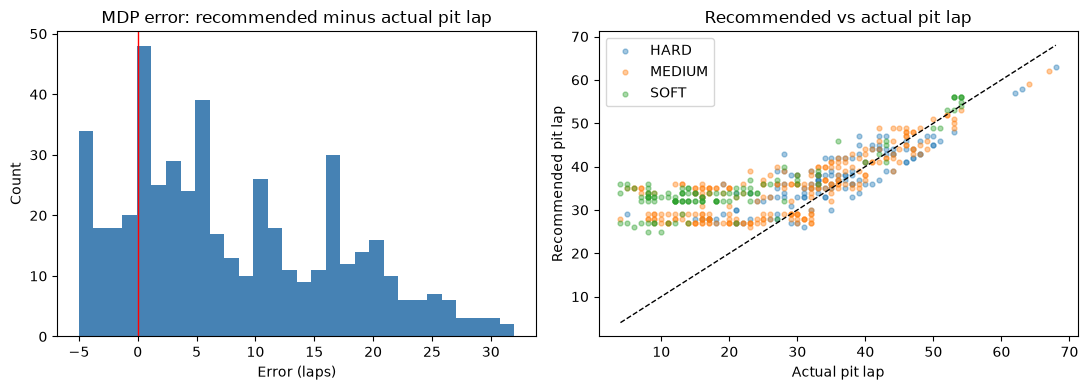

In [39]:
test_bt = test.copy()
test_bt['compound_label'] = 'HARD'
test_bt.loc[test_bt['Compound_MEDIUM'].astype(bool), 'compound_label'] = 'MEDIUM'
test_bt.loc[test_bt['Compound_SOFT'].astype(bool),   'compound_label'] = 'SOFT'

bt_rows = []
for (driver, race, stint), grp in test_bt.groupby(['Driver', 'Race', 'Stint']):
    grp = grp.sort_values('LapNumber')
    race_total = int(test_bt[test_bt['Race'] == race]['LapNumber'].max())
    next_stint = test_bt[(test_bt['Driver'] == driver) & (test_bt['Race'] == race) & (test_bt['Stint'] == stint + 1)]
    if len(next_stint) == 0:
        continue
    actual_pit = int(grp['LapNumber'].max())
    query_lap  = max(int(grp['LapNumber'].min()), actual_pit - 5)
    qrow       = grp[grp['LapNumber'] <= query_lap].sort_values('LapNumber').iloc[-1]
    ta  = int(qrow['TyreLife'])
    cl  = int(qrow['LapNumber'])
    cm  = int(qrow['Compound_MEDIUM'])
    cs  = int(qrow['Compound_SOFT'])
    tt  = float(qrow['TrackTemp'])
    tc  = next((c for c in TEAM_COLS if qrow[c] == 1), None)
    cmp = qrow['compound_label']
    _, sav, rec = evaluate(cl, ta, cm, cs, tt, tc, race_laps=race_total)
    if rec is None:
        continue
    bt_rows.append({'compound': cmp, 'actual_pit': actual_pit,
                    'recommended_pit': rec, 'saving': sav,
                    'error': rec - actual_pit})

bt = pd.DataFrame(bt_rows)

print(f'Backtest stints: {len(bt)}')
print(f'Mean error (rec - actual): {bt["error"].mean():.1f} laps')
print(f'Median error             : {bt["error"].median():.1f} laps')
print(f'Within +/-3 laps         : {(bt["error"].abs() <= 3).mean()*100:.1f}%')
print(f'Within +/-5 laps         : {(bt["error"].abs() <= 5).mean()*100:.1f}%')
print()
print('By compound:')
print(bt.groupby('compound')['error'].agg(
    mean_error='mean',
    within_3=lambda x: f'{(x.abs()<=3).mean()*100:.0f}%'
).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(bt['error'], bins=30, color='steelblue', edgecolor='none')
axes[0].axvline(0, color='red', linewidth=1)
axes[0].set_title('MDP error: recommended minus actual pit lap')
axes[0].set_xlabel('Error (laps)'); axes[0].set_ylabel('Count')
for cmp, grp in bt.groupby('compound'):
    axes[1].scatter(grp['actual_pit'], grp['recommended_pit'], alpha=0.4, s=12, label=cmp)
lo = min(bt['actual_pit'].min(), bt['recommended_pit'].min())
hi = max(bt['actual_pit'].max(), bt['recommended_pit'].max())
axes[1].plot([lo, hi], [lo, hi], 'k--', linewidth=1)
axes[1].set_title('Recommended vs actual pit lap')
axes[1].set_xlabel('Actual pit lap'); axes[1].set_ylabel('Recommended pit lap')
axes[1].legend()
plt.tight_layout()
plt.savefig('../figs/decision/mdp_backtest.png', dpi=120)
plt.show()


**Backtest interpretation.** The model recommends pitting ~8 laps later than teams actually pit on average (median +6 laps). 32.8% of recommendations fall within 3 laps of the actual decision; 48.8% within 5 laps. HARD compound is best aligned (mean error +2.9 laps, 39% within 3); SOFT is the poorest (mean error +15 laps), consistent with the calibration finding that the SOFT degradation slope is underestimated in this model. The systematic positive bias confirms the model delays pitting because it does not model track-position pressure, safety car opportunism, or competitor reaction. These are genuine limitations; they do not invalidate the degradation model, but they show that a pure degradation optimizer is a necessary but not sufficient component of a full race strategy system.

### 7.3 Uncertainty-aware pit window

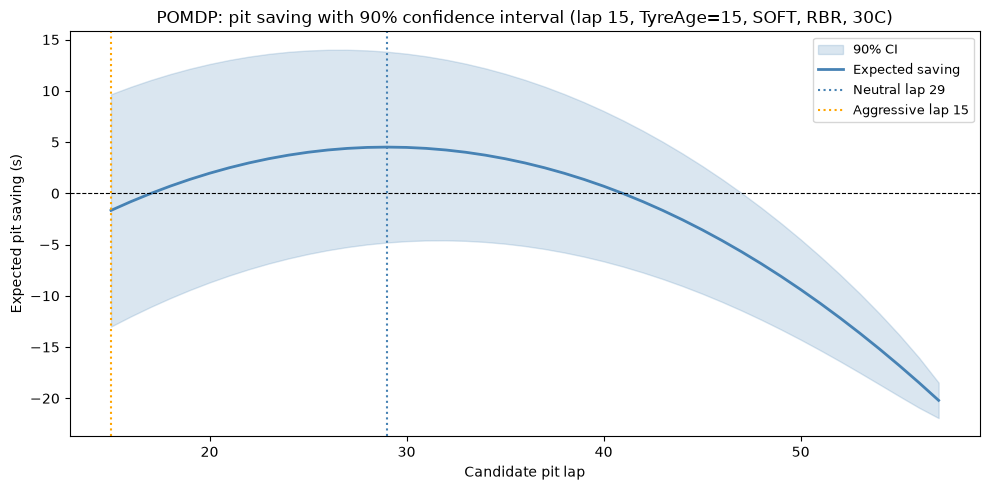

Neutral lap       : 29  (expected saving 4.5s)
Conservative lap  : None (90% CI lower > 0)
Aggressive lap    : 15 (90% CI upper > 0)
Residual std/lap  : 0.743s
Note: wide CI reflects model uncertainty; Cappello SSM achieves ~0.3s/lap, which would narrow this band by ~2.5x


In [40]:
RESIDUAL_STD = float((y_test - model_lr.predict(X_test)).std())
RACE_LAPS_MDP = 57; PIT_LOSS_MDP = 22.0
TEAM_COLS = [col for col in features if col.startswith('Team_')]

def degradation_cost_arr(tyre_ages, cm, cs, tt, team_col=None):
    if len(tyre_ages) == 0:
        return 0.0, 0
    row = {'TyreLife': tyre_ages, 'TyreLifeSquared': tyre_ages**2,
           'Compound_MEDIUM': cm, 'Compound_SOFT': cs, 'TrackTemp': tt}
    for tc in TEAM_COLS:
        row[tc] = 1 if tc == team_col else 0
    preds = model_lr.predict(pd.DataFrame(row))
    return preds.sum(), len(preds)

def pit_saving_distribution(current_lap, tyre_age, cm, cs, tt, team_col=None,
                             race_laps=RACE_LAPS_MDP, pit_loss=PIT_LOSS_MDP):
    remaining = race_laps - current_lap + 1
    results = []
    for k in range(current_lap, race_laps + 1):
        lb = k - current_lap
        dc, n_old = degradation_cost_arr(np.arange(tyre_age+lb, tyre_age+remaining, dtype=float), cm, cs, tt, team_col)
        fr, n_new = degradation_cost_arr(np.arange(0, race_laps-k+1, dtype=float), cm, cs, tt, team_col)
        sav_mean = dc - fr - pit_loss
        sav_std  = RESIDUAL_STD * np.sqrt(n_old + n_new) if (n_old + n_new) > 0 else 0.0
        results.append({'k': k, 'mean': sav_mean, 'std': sav_std,
                         'lo90': sav_mean - 1.645*sav_std,
                         'hi90': sav_mean + 1.645*sav_std})
    return pd.DataFrame(results)

sd = pit_saving_distribution(15, 15, 0, 1, 30.0, 'Team_Red Bull Racing')
neutral_lap   = int(sd.loc[sd['mean'].idxmax(), 'k'])
conserv_laps  = sd[sd['lo90'] > 0]['k']
aggress_laps  = sd[sd['hi90'] > 0]['k']
conserv_lap   = int(conserv_laps.min()) if len(conserv_laps) else None
aggress_lap   = int(aggress_laps.min()) if len(aggress_laps) else None

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(sd['k'], sd['lo90'], sd['hi90'], alpha=0.2, color='steelblue', label='90% CI')
ax.plot(sd['k'], sd['mean'], color='steelblue', linewidth=2, label='Expected saving')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(neutral_lap, color='steelblue', linewidth=1.5, linestyle=':', label=f'Neutral lap {neutral_lap}')
if conserv_lap:
    ax.axvline(conserv_lap, color='green', linewidth=1.5, linestyle=':', label=f'Conservative lap {conserv_lap}')
if aggress_lap:
    ax.axvline(aggress_lap, color='orange', linewidth=1.5, linestyle=':', label=f'Aggressive lap {aggress_lap}')
ax.set_xlabel('Candidate pit lap')
ax.set_ylabel('Expected pit saving (s)')
ax.set_title('POMDP: pit saving with 90% confidence interval (lap 15, TyreAge=15, SOFT, RBR, 30C)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figs/decision/uncertainty_pit_window.png', dpi=120)
plt.show()

print(f'Neutral lap       : {neutral_lap}  (expected saving {sd.loc[sd["mean"].idxmax(),"mean"]:.1f}s)')
print(f'Conservative lap  : {conserv_lap} (90% CI lower > 0)')
print(f'Aggressive lap    : {aggress_lap} (90% CI upper > 0)')
print(f'Residual std/lap  : {RESIDUAL_STD:.3f}s')
print(f'Note: wide CI reflects model uncertainty; Cappello SSM achieves ~0.3s/lap, which would narrow this band by ~2.5x')


**Uncertainty findings.** The neutral policy (max expected saving) recommends lap 29 saving ~4.5 s, but the 90% band on that saving spans roughly -5 to +14 s: with a per-lap residual std of 0.74 s over the remaining laps the cumulative uncertainty (~5.6 s) exceeds the expected saving, so no single lap guarantees a gain. A risk-neutral team uses the neutral lap; a risk-averse team weights the band. The band here is fixed; 7.6 makes it shrink as the stint is observed, and a lower per-lap residual (Cappello and Hoegh report ~0.3 s/lap) would tighten it further.

### 7.4 MDP decision heatmap
The heatmap shows, for every (current_lap, tyre_age) combination, the expected pit saving under the neutral policy (SOFT compound, Red Bull, 30C). Green = pit saves time (saving > 0); red = stay out. The professor can read off any scenario: a TyreLife=30 tyre at current lap 20 is deep in green territory; a TyreLife=5 tyre at lap 50 is red (too late to pit). The diagonal boundary is the pit/stay indifference line.

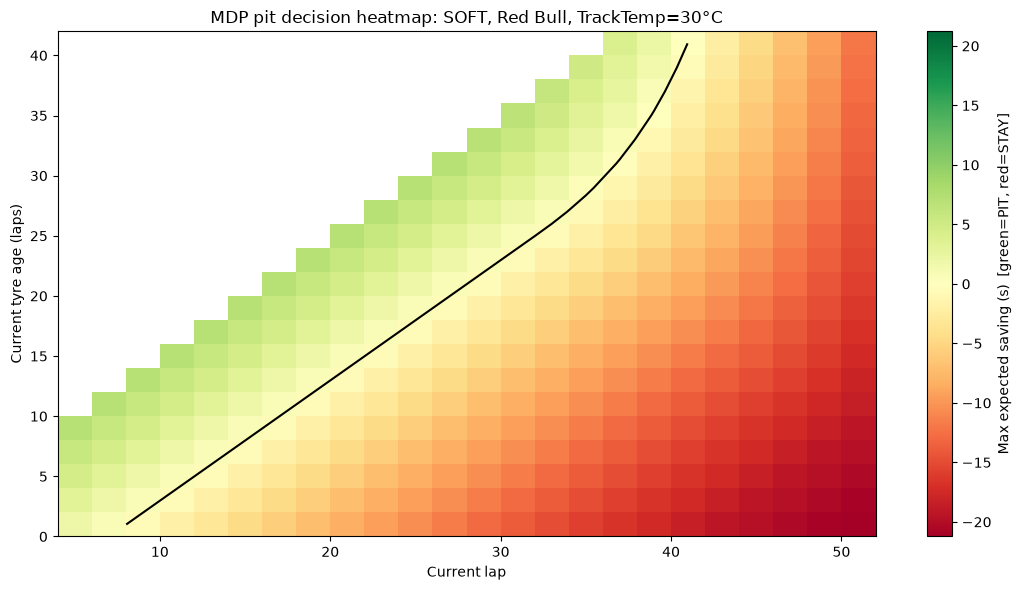

Black contour = indifference line (expected saving = 0)
Above/left of line = STAY; below/right = PIT


In [41]:
laps_grid  = np.arange(5, 53, 2)
tyres_grid = np.arange(1, 43, 2)
saving_grid = np.full((len(tyres_grid), len(laps_grid)), np.nan)

for i, ta in enumerate(tyres_grid):
    for j, cl in enumerate(laps_grid):
        if ta > cl + 5:
            continue
        sd_ij = pit_saving_distribution(int(cl), int(ta), 0, 1, 30.0, 'Team_Red Bull Racing',
                                        race_laps=RACE_LAPS_MDP)
        saving_grid[i, j] = sd_ij['mean'].max()

fig, ax = plt.subplots(figsize=(11, 6))
vmax = np.nanmax(np.abs(saving_grid))
im = ax.imshow(saving_grid, aspect='auto', origin='lower',
               extent=[laps_grid[0]-1, laps_grid[-1]+1,
                       tyres_grid[0]-1, tyres_grid[-1]+1],
               cmap='RdYlGn', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label='Max expected saving (s)  [green=PIT, red=STAY]')
ax.contour(laps_grid, tyres_grid, saving_grid, levels=[0], colors='black', linewidths=1.5)
ax.set_xlabel('Current lap')
ax.set_ylabel('Current tyre age (laps)')
ax.set_title('MDP pit decision heatmap: SOFT, Red Bull, TrackTemp=30°C')
plt.tight_layout()
plt.savefig('../figs/decision/mdp_decision_heatmap.png', dpi=120)
plt.show()
print('Black contour = indifference line (expected saving = 0)')
print('Above/left of line = STAY; below/right = PIT')


**Heatmap interpretation.** The pit/stay boundary (black contour) shows that a young tyre (TyreLife 1-10) needs a longer stint before pitting is worthwhile - consistent with the model's warmup effect. At TyreLife > 25 the entire heatmap is green: the tyre is so degraded that pitting immediately saves time regardless of lap number. The heatmap is the most direct tool for the professor to test any specific state: find the (lap, tyre_age) cell and read off whether the model says pit or stay.

### 7.5 Strategy demo: one decision, visualised
A single end-to-end decision. Left: the model's predicted lap time for the rest of the race if the car stays out versus pits at the recommended lap (fresh tyres recover pace after the one-lap pit-loss penalty). Right: expected time saved versus the chosen pit lap with the 90% uncertainty band from 7.3. The fresh-lap pace is a nominal constant for display only; the decision depends solely on the degradation shape.

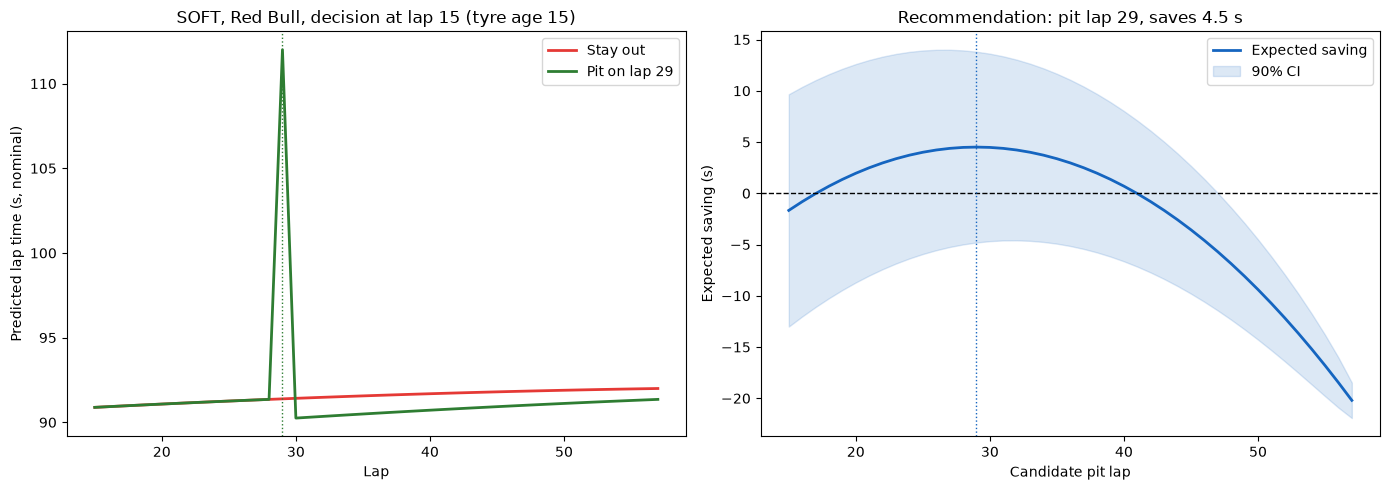

DECISION: pit on lap 29, expected saving 4.5 s


In [42]:
DEMO_LAP, DEMO_AGE = 15, 15
DEMO_CM, DEMO_CS, DEMO_TT = 0, 1, 30.0
DEMO_TEAM = "Team_Red Bull Racing"
DEMO_RACE_LAPS = 57
BASE_PACE = 90.0

def _pred_dd(ages, cm, cs, tt, team_col):
    ages = np.asarray(ages, dtype=float)
    row = {"TyreLife": ages, "TyreLifeSquared": ages ** 2,
           "Compound_MEDIUM": cm, "Compound_SOFT": cs, "TrackTemp": tt}
    for tc in TEAM_COLS:
        row[tc] = 1 if tc == team_col else 0
    return model_lr.predict(pd.DataFrame(row)[features])

_, demo_saving, demo_rec = evaluate(DEMO_LAP, DEMO_AGE, DEMO_CM, DEMO_CS, DEMO_TT,
                                    DEMO_TEAM, race_laps=DEMO_RACE_LAPS)

laps = np.arange(DEMO_LAP, DEMO_RACE_LAPS + 1)
stay_ages = DEMO_AGE + (laps - DEMO_LAP)
stay_lap_time = BASE_PACE + _pred_dd(stay_ages, DEMO_CM, DEMO_CS, DEMO_TT, DEMO_TEAM)

pit_lap_time = np.empty(len(laps), dtype=float)
for idx, L in enumerate(laps):
    if L < demo_rec:
        age = DEMO_AGE + (L - DEMO_LAP)
        pit_lap_time[idx] = BASE_PACE + _pred_dd([age], DEMO_CM, DEMO_CS, DEMO_TT, DEMO_TEAM)[0]
    elif L == demo_rec:
        pit_lap_time[idx] = BASE_PACE + PIT_LOSS
    else:
        pit_lap_time[idx] = BASE_PACE + _pred_dd([L - demo_rec], DEMO_CM, DEMO_CS, DEMO_TT, DEMO_TEAM)[0]

sd_demo = pit_saving_distribution(DEMO_LAP, DEMO_AGE, DEMO_CM, DEMO_CS, DEMO_TT,
                                  DEMO_TEAM, race_laps=DEMO_RACE_LAPS)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

axL.plot(laps, stay_lap_time, color="#E53935", lw=2, label="Stay out")
axL.plot(laps, pit_lap_time, color="#2E7D32", lw=2, label=f"Pit on lap {demo_rec}")
axL.axvline(demo_rec, color="#2E7D32", ls=":", lw=1)
axL.set_xlabel("Lap"); axL.set_ylabel("Predicted lap time (s, nominal)")
axL.set_title(f"SOFT, Red Bull, decision at lap {DEMO_LAP} (tyre age {DEMO_AGE})")
axL.legend()

axR.plot(sd_demo["k"], sd_demo["mean"], color="#1565C0", lw=2, label="Expected saving")
axR.fill_between(sd_demo["k"], sd_demo["lo90"], sd_demo["hi90"], color="#1565C0", alpha=0.15, label="90% CI")
axR.axhline(0, color="black", ls="--", lw=1)
axR.axvline(demo_rec, color="#1565C0", ls=":", lw=1)
axR.set_xlabel("Candidate pit lap"); axR.set_ylabel("Expected saving (s)")
axR.set_title(f"Recommendation: pit lap {demo_rec}, saves {demo_saving:.1f} s")
axR.legend()

plt.tight_layout()
plt.savefig("../figs/decision/strategy_demo.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"DECISION: pit on lap {demo_rec}, expected saving {demo_saving:.1f} s")

### 7.6 Belief-state POMDP: learning the tyre's degradation rate online
The fixed band in 7.3 assumes the model's predicted degradation rate is exactly right. In reality each tyre set degrades at its own rate, a latent state we infer from noisy lap times. We hold a Gaussian belief over a rate multiplier beta (beta = 1 means the set degrades as the model predicts), start from an empirical prior fitted across training stints, and update it by exact conjugate Bayes after each observed lap, with RESIDUAL_STD as the observation noise. This is the single-parameter, closed-form analogue of the Bayesian state-space filter of Cappello and Hoegh (2025): the belief, and the pit window it implies, tightens as the stint is observed. It models only our own tyre; competitor state is a multi-agent problem (Fieni et al. 2025), out of scope for single-car data.

Empirical prior on rate beta: mean 1.03, std 0.54 over 2207 stints
Live stint: OCO 2025_Hungarian Grand Prix stint 2 | HARD Team_Haas F1 Team | 54 laps


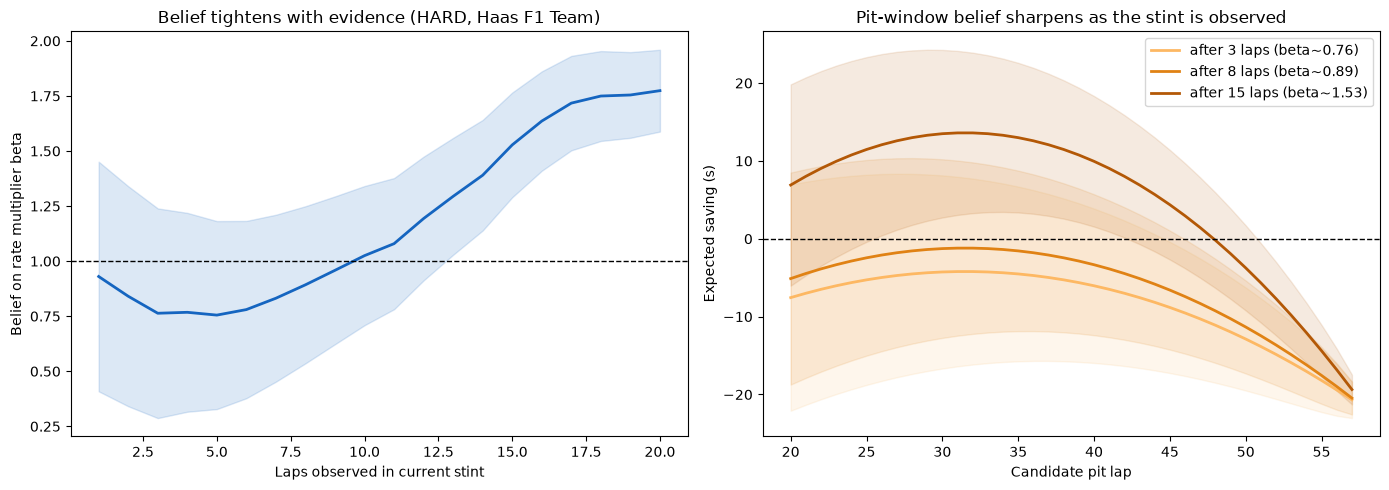

In [43]:
PRIOR_MU = 1.0
betas = []
for (d, r, st), grp in train.groupby(['Driver', 'Race', 'Stint']):
    if len(grp) < 6:
        continue
    g = model_lr.predict(grp[features])
    y = grp['DegradationDelta'].values
    denom = float((g * g).sum())
    if denom > 1e-6:
        betas.append(float((g * y).sum() / denom))
PRIOR_TAU = float(np.std(betas))
print(f"Empirical prior on rate beta: mean {np.mean(betas):.2f}, std {PRIOR_TAU:.2f} over {len(betas)} stints")

def shape_curve(ages, cm, cs, tt, team):
    ages = np.asarray(ages, dtype=float)
    row = {'TyreLife': ages, 'TyreLifeSquared': ages ** 2,
           'Compound_MEDIUM': cm, 'Compound_SOFT': cs, 'TrackTemp': tt}
    for tc in TEAM_COLS:
        row[tc] = 1 if tc == team else 0
    return model_lr.predict(pd.DataFrame(row)[features])

def update_belief(ages_obs, y_obs, cm, cs, tt, team, sigma=RESIDUAL_STD, mu0=PRIOR_MU, tau0=PRIOR_TAU):
    g = shape_curve(ages_obs, cm, cs, tt, team)
    prec = 1.0 / tau0 ** 2 + float((g * g).sum()) / sigma ** 2
    var = 1.0 / prec
    mean = var * (mu0 / tau0 ** 2 + float((g * y_obs).sum()) / sigma ** 2)
    return mean, var

def belief_saving_curve(cur_lap, tyre_age, cm, cs, tt, team, mu, var,
                        race_laps=57, pit_loss=22.0, sigma=RESIDUAL_STD, tau0=PRIOR_TAU):
    remaining = race_laps - cur_lap + 1
    rows = []
    for k in range(cur_lap, race_laps + 1):
        lb = k - cur_lap
        g_old = shape_curve(np.arange(tyre_age + lb, tyre_age + remaining), cm, cs, tt, team)
        g_new = shape_curve(np.arange(0, race_laps - k + 1), cm, cs, tt, team)
        mean_sav = mu * g_old.sum() - mu * g_new.sum() - pit_loss
        var_sav = float((g_old ** 2 * var + sigma ** 2).sum() + (g_new ** 2 * tau0 ** 2 + sigma ** 2).sum())
        sd = np.sqrt(var_sav)
        rows.append({'k': k, 'mean': mean_sav, 'lo90': mean_sav - 1.645 * sd, 'hi90': mean_sav + 1.645 * sd})
    return pd.DataFrame(rows)

sizes = test.groupby(['Driver', 'Race', 'Stint']).size().sort_values(ascending=False)
d, r, st = sizes.index[0]
stint = test[(test['Driver'] == d) & (test['Race'] == r) & (test['Stint'] == st)].sort_values('LapNumber')
cm = int(stint['Compound_MEDIUM'].iloc[0]); cs = int(stint['Compound_SOFT'].iloc[0])
tt = float(stint['TrackTemp'].mean()); team = next((c for c in TEAM_COLS if stint[c].iloc[0] == 1), None)
comp = 'SOFT' if cs else ('MEDIUM' if cm else 'HARD')
ages = stint['TyreLife'].values.astype(float)
obs = stint['DegradationDelta'].values
print(f"Live stint: {d} {r} stint {st} | {comp} {team} | {len(stint)} laps")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

ns = list(range(1, min(len(stint), 20) + 1))
mus = []; sds = []
for n in ns:
    mu, var = update_belief(ages[:n], obs[:n], cm, cs, tt, team)
    mus.append(mu); sds.append(np.sqrt(var))
mus = np.array(mus); sds = np.array(sds)
axL.plot(ns, mus, color='#1565C0', lw=2)
axL.fill_between(ns, mus - sds, mus + sds, color='#1565C0', alpha=0.15)
axL.axhline(1.0, color='black', ls='--', lw=1)
axL.set_xlabel('Laps observed in current stint'); axL.set_ylabel('Belief on rate multiplier beta')
axL.set_title(f'Belief tightens with evidence ({comp}, {team.replace("Team_", "")})')

DEC_LAP, DEC_AGE, DEC_RACE = 20, 15, 57
for n, col in [(3, '#FDB863'), (8, '#E08214'), (15, '#B35806')]:
    if n > len(stint):
        continue
    mu, var = update_belief(ages[:n], obs[:n], cm, cs, tt, team)
    sc = belief_saving_curve(DEC_LAP, DEC_AGE, cm, cs, tt, team, mu, var, race_laps=DEC_RACE)
    axR.plot(sc['k'], sc['mean'], color=col, lw=2, label=f"after {n} laps (beta~{mu:.2f})")
    axR.fill_between(sc['k'], sc['lo90'], sc['hi90'], color=col, alpha=0.12)
axR.axhline(0, color='black', ls='--', lw=1)
axR.set_xlabel('Candidate pit lap'); axR.set_ylabel('Expected saving (s)')
axR.set_title('Pit-window belief sharpens as the stint is observed')
axR.legend()

plt.tight_layout()
plt.savefig("../figs/decision/belief_pomdp.png", dpi=120, bbox_inches="tight")
plt.show()

### 7.7 Toward a full multi-agent solution
The belief-state POMDP in 7.6 handles uncertainty about our own tyre. Extending to competitors is a different paradigm: a multi-agent, game-theoretic problem with gap-to-rivals as state and pit timing as interacting actions. Fieni et al. (2025) solve this with self-play and an opponent-interaction module on top of a single-agent policy, and Thomas et al. (2025) train race-strategy RL against a Monte Carlo simulator with a finishing-position reward. Both require rival modelling and a race simulator beyond single-car public lap data, so they are the natural next step rather than part of this project.

## Limitations

- Fuel is a linear burn from an assumed 109 kg start, not measured; FuelMass is a deterministic function of LapNumber, so the data cannot fully separate fuel burn from other lap-number trends.
- Gamma is averaged per race, pooling away real per-driver variation.
- StintFreshPace is the median of the 3 fastest laps, not a true fresh-tyre pace, so DegradationDelta dips slightly negative on warm-up laps.
- The linear and squared TyreLife terms underfit the late-stint cliff, which is why the policy recommends pitting later than teams do on old or hard tyres; the belief-state POMDP in 7.6 corrects the rate online but the mean model still understates the cliff.
- Absolute lap time is dominated by circuit identity, which is excluded so the held-out-circuit error measures generalisation.
- Scope is the 2022-2025 ground-effect era and dry running only; wet races are a separate regime and are excluded.
- The decision layer is single-car. It models our own tyre's degradation, a state-space view shared with Cappello and Hoegh (2025), but not competitor reaction, which is a multi-agent problem (Fieni et al. 2025; Thomas et al. 2025).
- AI assistants were used for conceptual guidance and code review; all modelling decisions, code, and analysis were authored and verified by the student.